In [ ]:
from datetime import datetime
from getpass import getpass

rdm_url = 'http://localhost:5001/'
admin_rdm_url = 'http://localhost:8001/'
idp_name_1 = 'FakeCAS'
idp_username_1 = None
idp_password_1 = None
idp_name_2 = 'FakeCAS'
idp_username_2 = None
idp_password_2 = None
weko_url = 'https://weko3.rdm.example.com/'
weko_admin_email = None
weko_admin_password = None
weko_user_email = None
weko_user_password = None
weko_institution_name = 'Massachusetts Institute of Technology [Test]'
weko_index_name = 'GRDM-Collaboration-Test-VR-1'
default_result_path = None
close_on_fail = False
transition_timeout = 60000
browser_type = 'chromium'
ignore_https_errors = False
project_name = None
oauth_application_name = None
project_url = None
default_storage_label = 'NII Storage'

In [2]:
import asyncio
import importlib
import os
import shutil
import tempfile
from urllib.parse import urljoin, urlparse

if idp_username_2 is None:
    prompt = f"Username for {idp_name_2 or 'admin account'}: "
    idp_username_2 = input(prompt)
if idp_password_2 is None:
    prompt = f"Password for {idp_username_2}: "
    idp_password_2 = getpass(prompt)

if idp_username_1 is None:
    prompt = f"Username for {idp_name_1 or 'user account'}: "
    idp_username_1 = input(prompt)
if idp_password_1 is None:
    prompt = f"Password for {idp_username_1}: "
    idp_password_1 = getpass(prompt)

if weko_admin_email is None:
    weko_admin_email = input('WEKO admin email: ')
if weko_admin_password is None:
    weko_admin_password = getpass('WEKO admin password: ')
if weko_user_email is None:
    weko_user_email = input('WEKO user email: ')
if weko_user_password is None:
    weko_user_password = getpass('WEKO user password: ')
if weko_institution_name is None:
    weko_institution_name = input('機関名 (例: GakuNin RDM IdP): ')
if weko_index_name is None:
    weko_index_name = 'TestJ'

if project_name is None:
    project_name = datetime.now().strftime('TEST-WEKO-%Y%m%d%H%M')
if oauth_application_name is None:
    oauth_application_name = datetime.now().strftime('TEST-WEKO-APP-%Y%m%d%H%M')



# プロジェクトに対するWEKOアドオンの登録

- サブシステム名: アドオン
- ページ/アドオン: WEKO
- 機能分類: プロジェクト設定
- シナリオ名: プロジェクトへの有効化
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM一般ユーザー, WEKO管理者、ユーザーadmin: GRDM統合管理者)

## ウェブブラウザの新規プライベートウィンドウでGRDM統合管理者画面を表示する

GRDM統合管理者画面のログインページが表示されること

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir


'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj8kmxygy'

In [ ]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, ignore_https_errors=ignore_https_errors)

Start epoch: 1764939344.062012 seconds


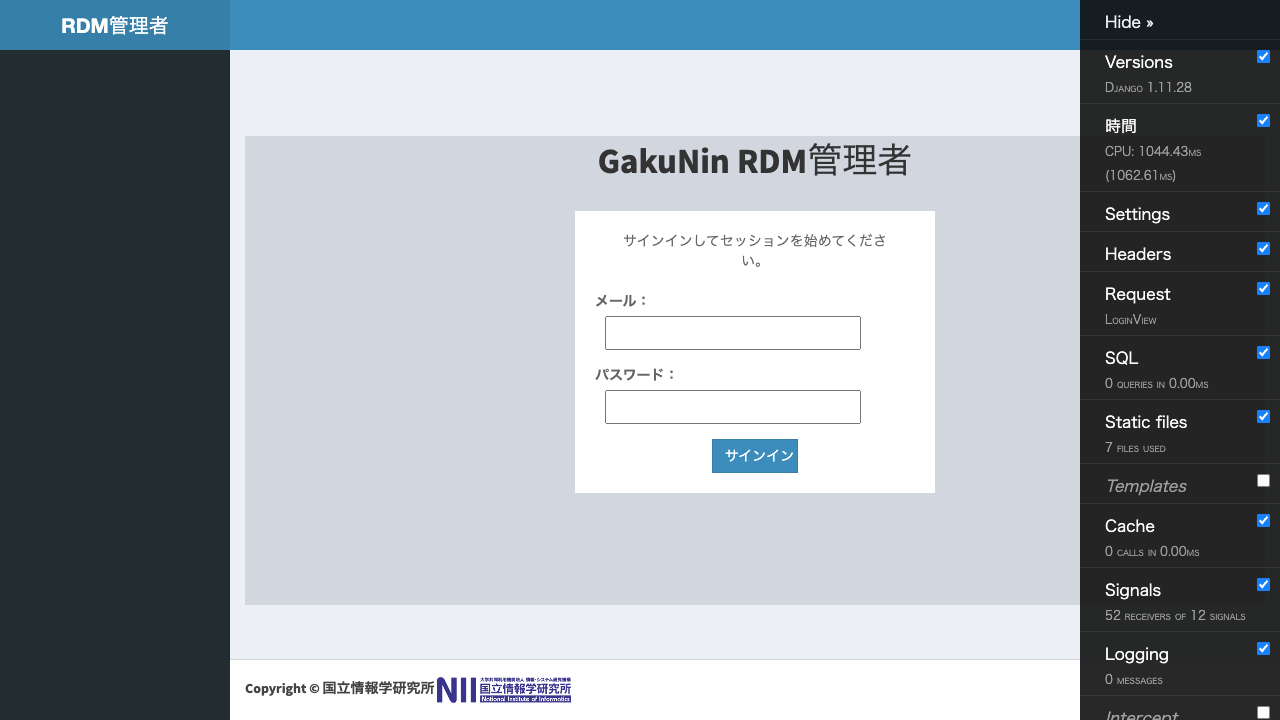

In [73]:
async def _step(page):
    await page.goto(admin_rdm_url)
    await expect(page.locator('//form[@id = "login-form"] | //div[contains(@class, "login-logo")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step, new_page=True)


## IdPを利用し、ユーザーadminとしてログインする

GRDM統合管理者画面が表示されること

In [ ]:
async def _step(page):
    await grdm.login_as_admin(page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout)
    await expect(page.locator('//a[@href = "/addons/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## アドオン利用制御をクリックする

機関一覧が表示されること

Start epoch: 1764939352.0127301 seconds


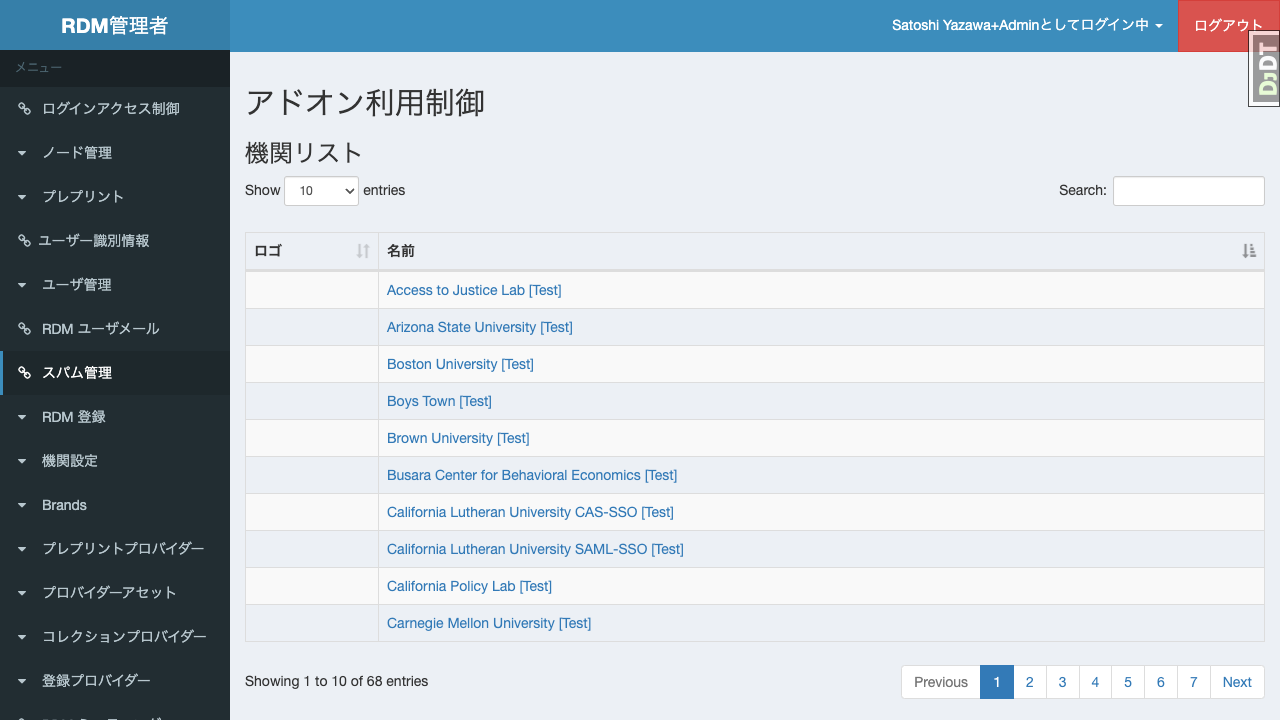

In [75]:
async def _step(page):
    await page.locator('//a[@href = "/addons/"]').click()
    await expect(page.locator('//input[@type = "search"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## テストユーザーの所属機関をクリックする

アドオン利用制御画面に JAIRO Cloud が表示されること

Start epoch: 1764939353.244365 seconds


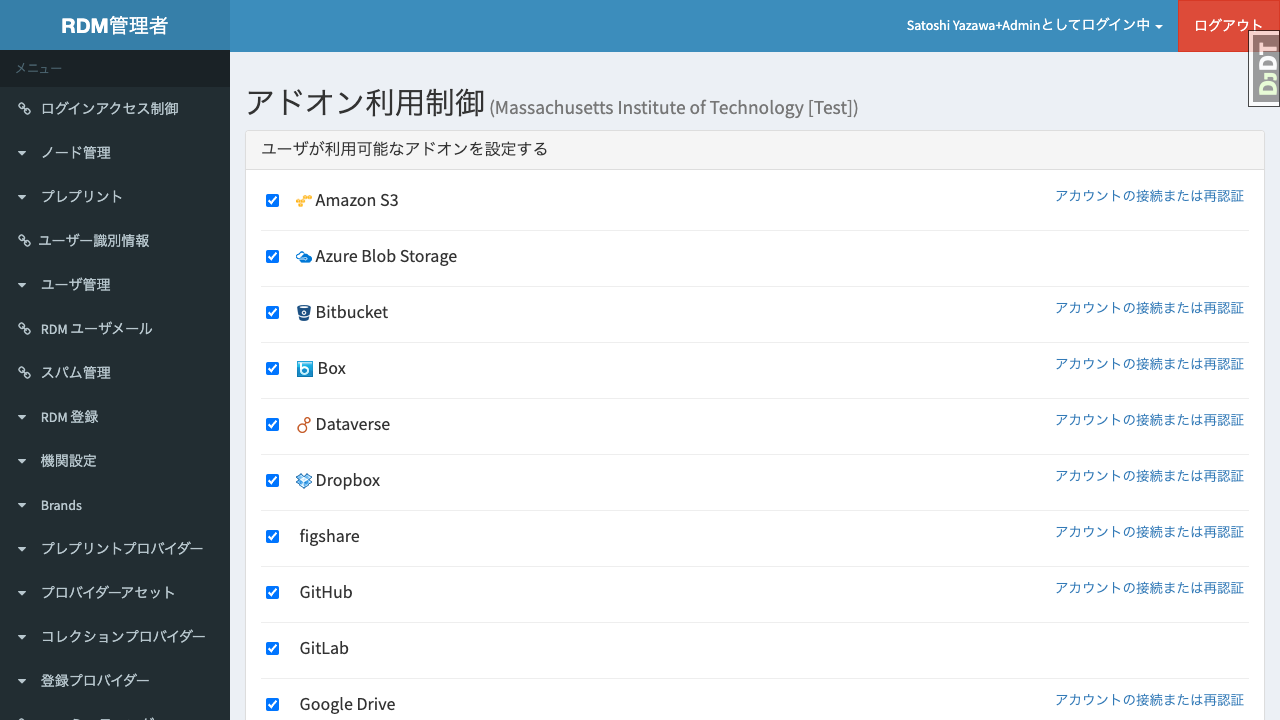

In [76]:
async def _step(page):
    await page.locator('//input[@type = "search"]').fill(weko_institution_name)
    institution_link = page.locator(f'//a[contains(text(), "{weko_institution_name}")]')
    await expect(institution_link).to_be_visible(timeout=transition_timeout)
    await institution_link.click()
    await expect(page.locator('//h4/span[text() = "JAIRO Cloud"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## JAIRO Cloud チェックボックスをチェック解除状態にする

チェックを解除する場合、「JAIRO Cloudを禁止しますか？」ダイアログが表示されるので、「次を入力して実行します。」で指示された文字列を入力し、「禁止」をクリックする。チェックボックスが解除状態になること

Start epoch: 1764939355.833956 seconds
JAIRO Cloud already disabled for this institution


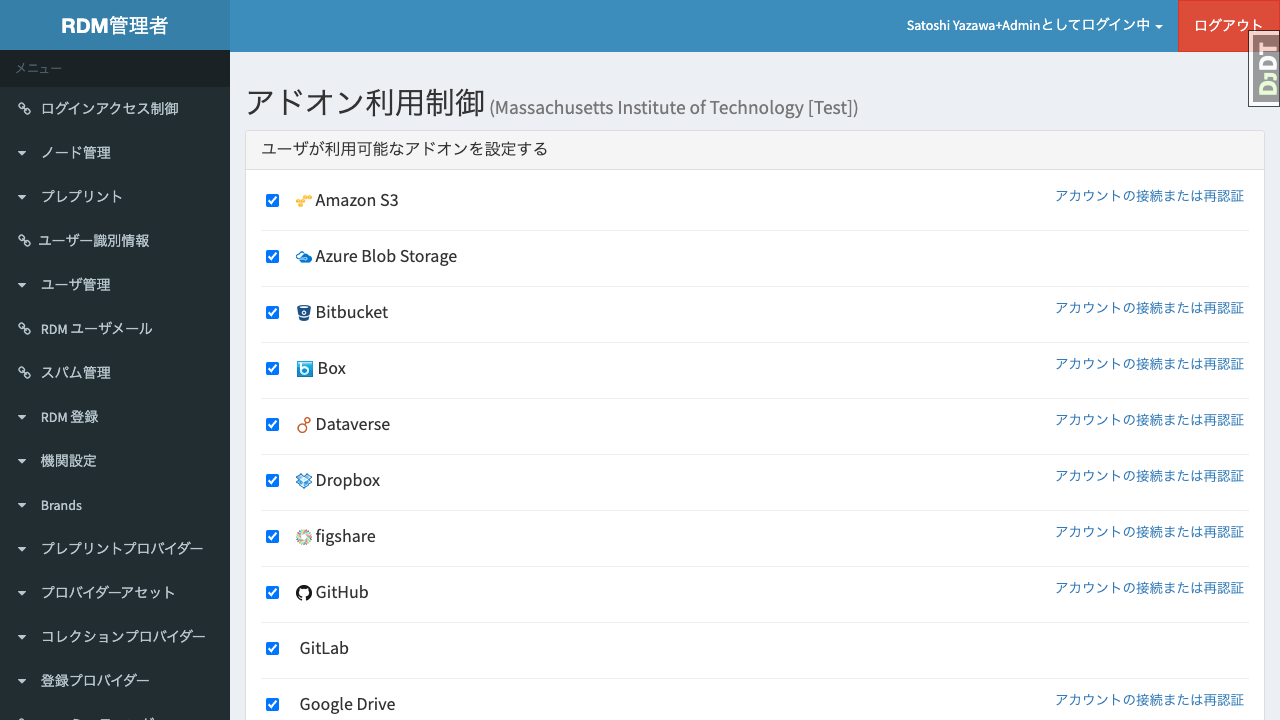

In [77]:
async def _step(page):
    checkbox = page.locator('//input[@type = "checkbox" and @data-addon-full-name = "JAIRO Cloud"]')
    if await checkbox.is_checked():
        await checkbox.click()
        confirm_key = (await page.locator('//h4[text() = "JAIRO Cloudを禁止しますか？"]/../..//strong').inner_text()).strip()
        await page.locator('//input[@id = "wekoDeleteKey"]').fill(confirm_key)
        await page.locator('//button[text() = "禁止"]').click()
        await expect(checkbox).not_to_be_checked(timeout=transition_timeout)
    else:
        print('JAIRO Cloud already disabled for this institution')

await run_pw(_step)


## 新規タブを開き、GRDMトップページを表示する

GRDMトップページが表示されること

Start epoch: 1764939356.085357 seconds


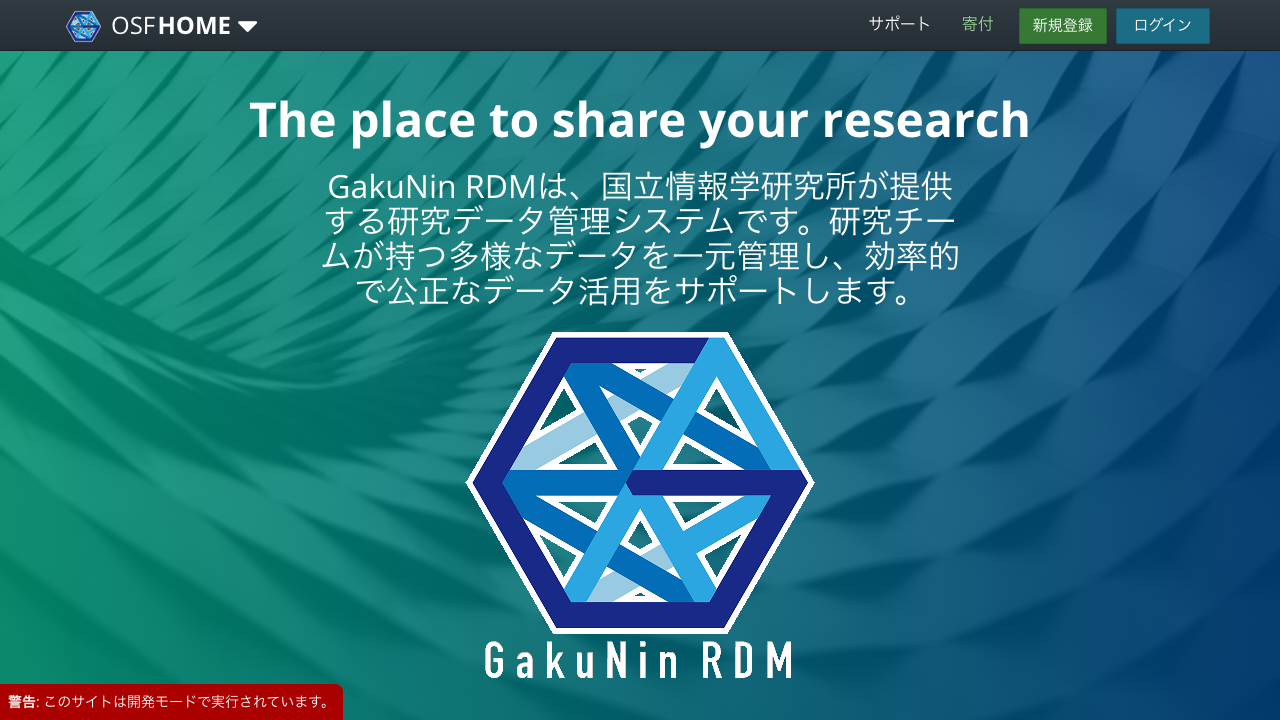

In [78]:
async def _step(page):
    await page.goto(rdm_url)
    consent_button = page.locator('//button[text() = "同意する"]')
    if await consent_button.count():
        await consent_button.click()
    await expect(page.locator('//button[text() = "ログイン"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step, new_page=True)


## IdPを利用し、既存ユーザー1としてログインする

GRDMダッシュボードが表示されること

In [ ]:
async def _step(page):
    await grdm.login(page, idp_name_2, idp_username_2, idp_password_2, transition_timeout=transition_timeout)
    await grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)

## ダッシュボードから「新規プロジェクト作成」をクリックする

「新規プロジェクトの作成」のダイアログが作成されること

Start epoch: 1764939364.7530189 seconds


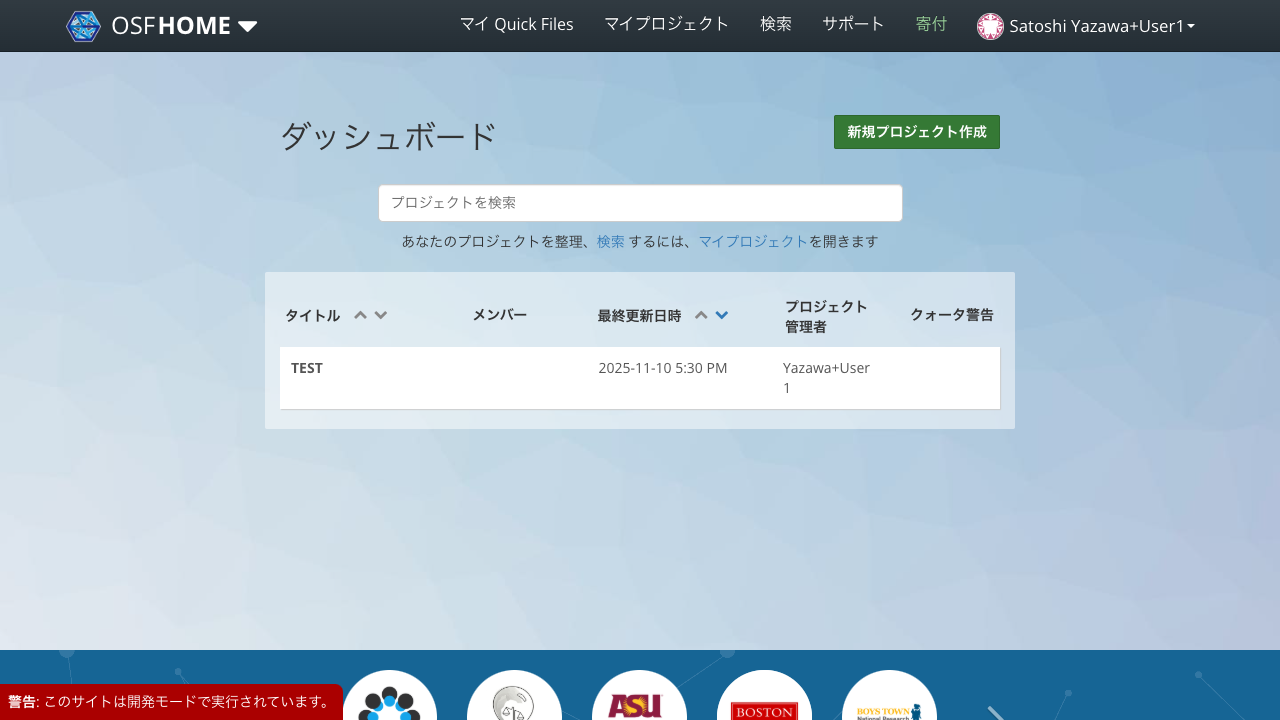

In [80]:
async def _step(page):
    trigger = page.locator('//*[@data-test-create-project-modal-button]')
    await expect(trigger).to_be_visible(timeout=transition_timeout)
    await trigger.click()
    await expect(page.locator('//input[@data-test-new-project-title]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## タイトル「TEST-WEKO-YYYYMMDDHHMM(実施時刻)」でプロジェクトを作成する

ダッシュボードのプロジェクト一覧に入力したプロジェクト名のプロジェクトが追加されること

Start epoch: 1764939364.9410748 seconds


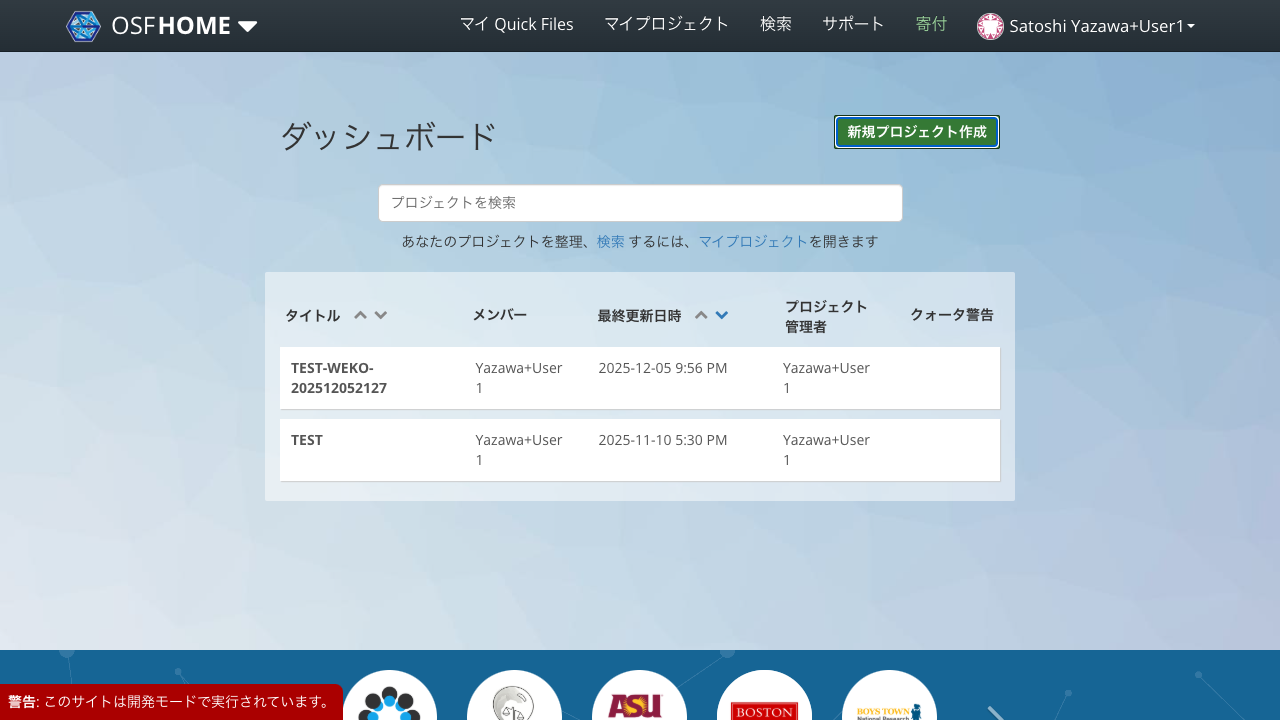

In [81]:
async def _step(page):
    await page.locator('//input[@data-test-new-project-title]').fill(project_name)
    await page.locator('//button[text() = "作成"]').click()
    await expect(page.locator('//button[@data-test-stay-here]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//button[@data-test-stay-here]').click()
    await expect(page.locator(f'//*[@data-test-dashboard-item-title and text() = "{project_name}"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

作成したプロジェクトのプロジェクトダッシュボードが表示されること

Start epoch: 1764939371.966675 seconds


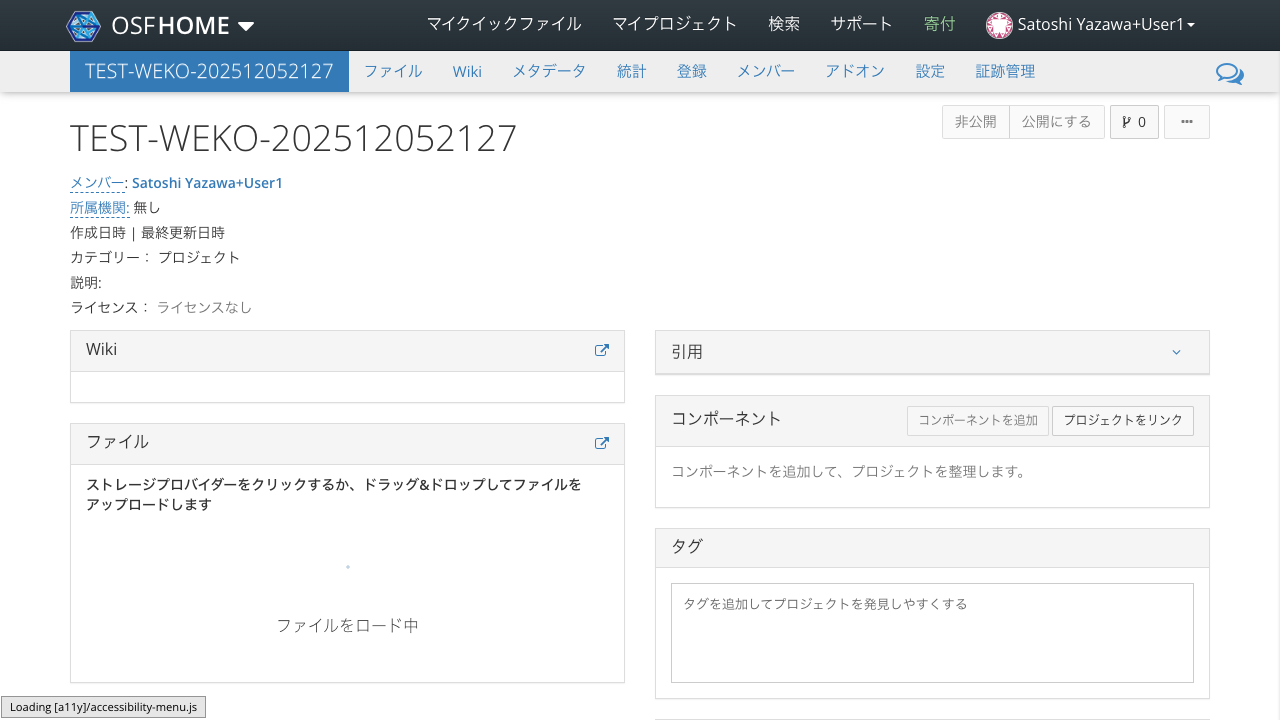

In [82]:
async def _step(page):
    project_link = page.locator(f'//*[@data-test-dashboard-item-title and text() = "{project_name}"]')
    await project_link.click()
    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    global project_url
    project_url = page.url

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

アドオン設定画面が表示されるが、JAIRO Cloudアドオンは存在していないこと

Start epoch: 1764939374.548769 seconds


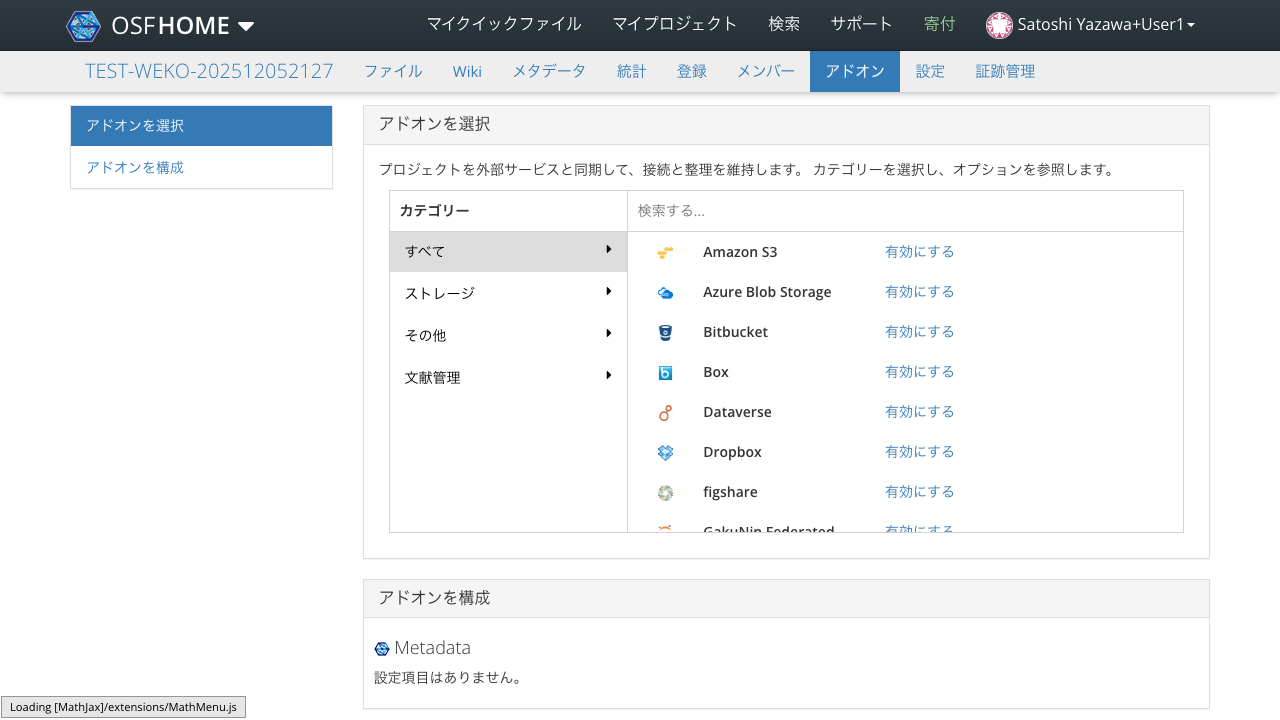

In [83]:
async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()
    await expect(page.locator('//h3[text() = "アドオンを選択"]')).to_be_visible(timeout=transition_timeout)
    addon_present = await page.locator('//div[@full_name = "JAIRO Cloud"]').count()
    if addon_present:
        raise AssertionError('JAIRO Cloud addon should not be available before enabling it for the institution')

await run_pw(_step)


## 統合管理者画面のタブに戻り、JAIRO Cloud チェックボックスをチェック状態にする

チェックボックスがチェック状態になること

Start epoch: 1764939375.825663 seconds


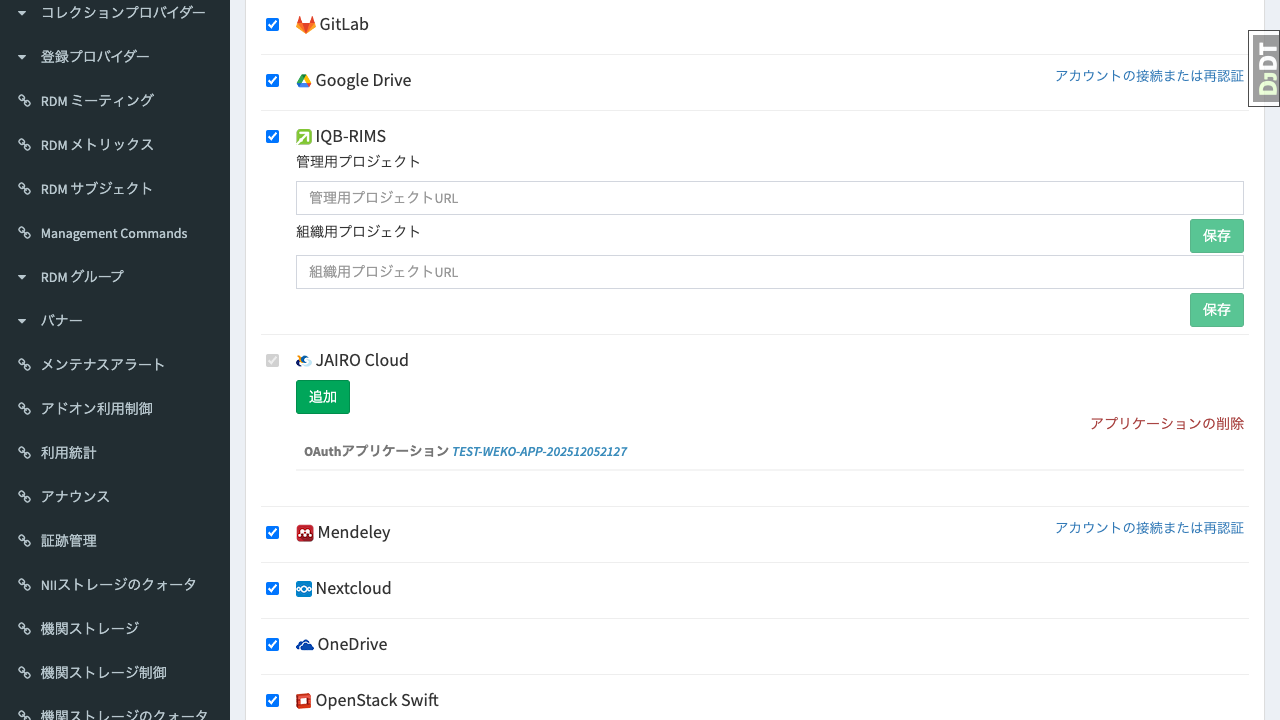

In [84]:
await close_latest_page()

async def _step(page):
    checkbox = page.locator('//input[@type = "checkbox" and @data-addon-full-name = "JAIRO Cloud"]')
    if not await checkbox.is_checked():
        await checkbox.click()
        await expect(checkbox).to_be_checked(timeout=transition_timeout)
    else:
        print('JAIRO Cloud already enabled for this institution')

await run_pw(_step)


## JAIRO CloudのOAuthアプリケーションがあれば、「アプリケーションの削除」をクリックする

OAuthアプリケーションが空になること

Start epoch: 1764939453.0631108 seconds
Existing JAIRO Cloud OAuth applications have been cleared


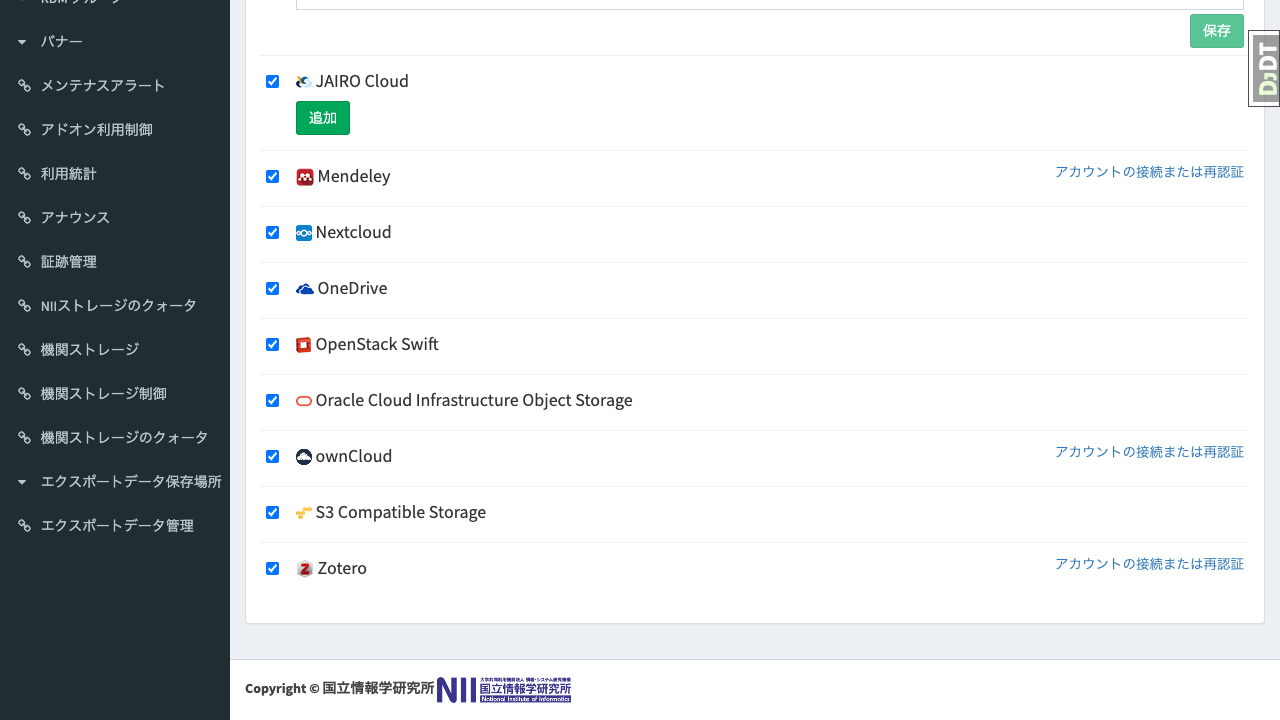

In [86]:
async def _step(page):
    locator = page.locator('//a[@href = "#wekoDisconnectAccount"]')
    while await locator.count() > 0:
        await locator.nth(0).click()
        await page.locator('//button[text() = "切断"]').click()
    print('Existing JAIRO Cloud OAuth applications have been cleared')

await run_pw(_step)


In [87]:
client_id = None
client_secret = None


## WEKOのURLを開く

WEKO3のトップ画面が表示されること

Start epoch: 1764939453.30016 seconds


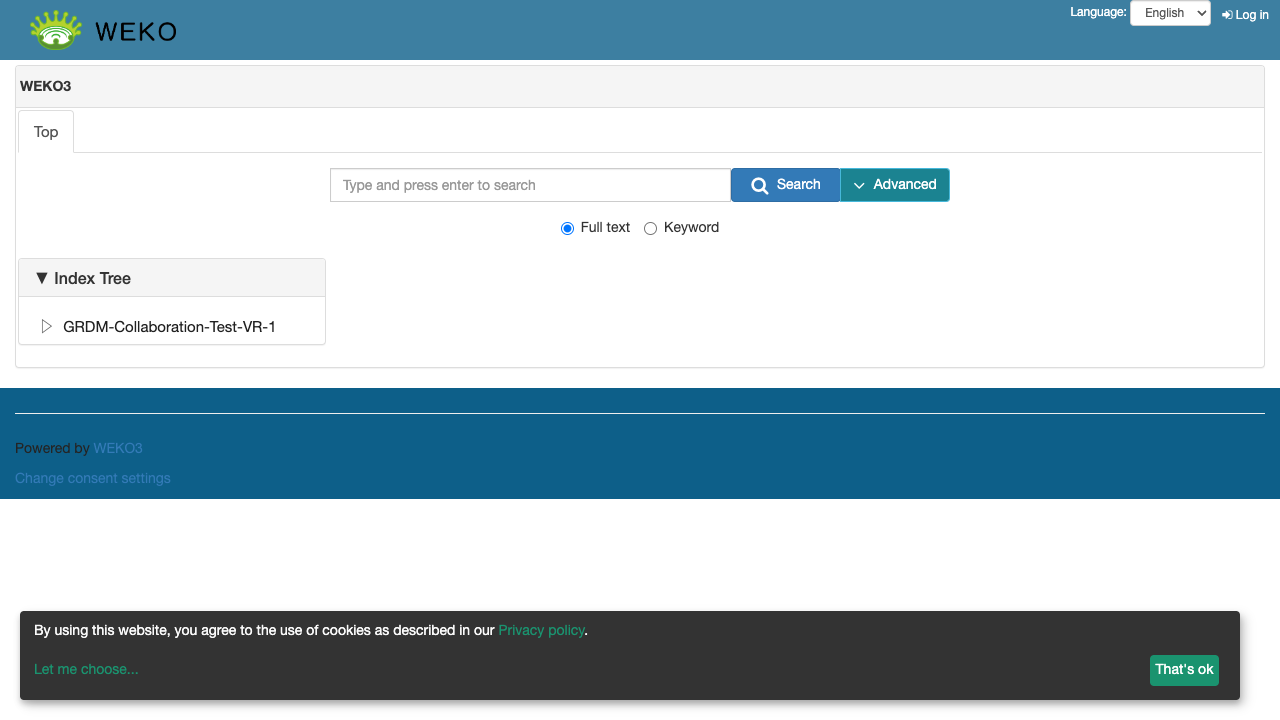

In [88]:
async def _step(page):
    await page.goto(weko_url)
    await expect(page.locator('//a[contains(@class, "login-button")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step, new_page=True)


## 「ログイン」をクリックする

WEKO3のログイン画面が表示されること

Start epoch: 1764939461.961528 seconds


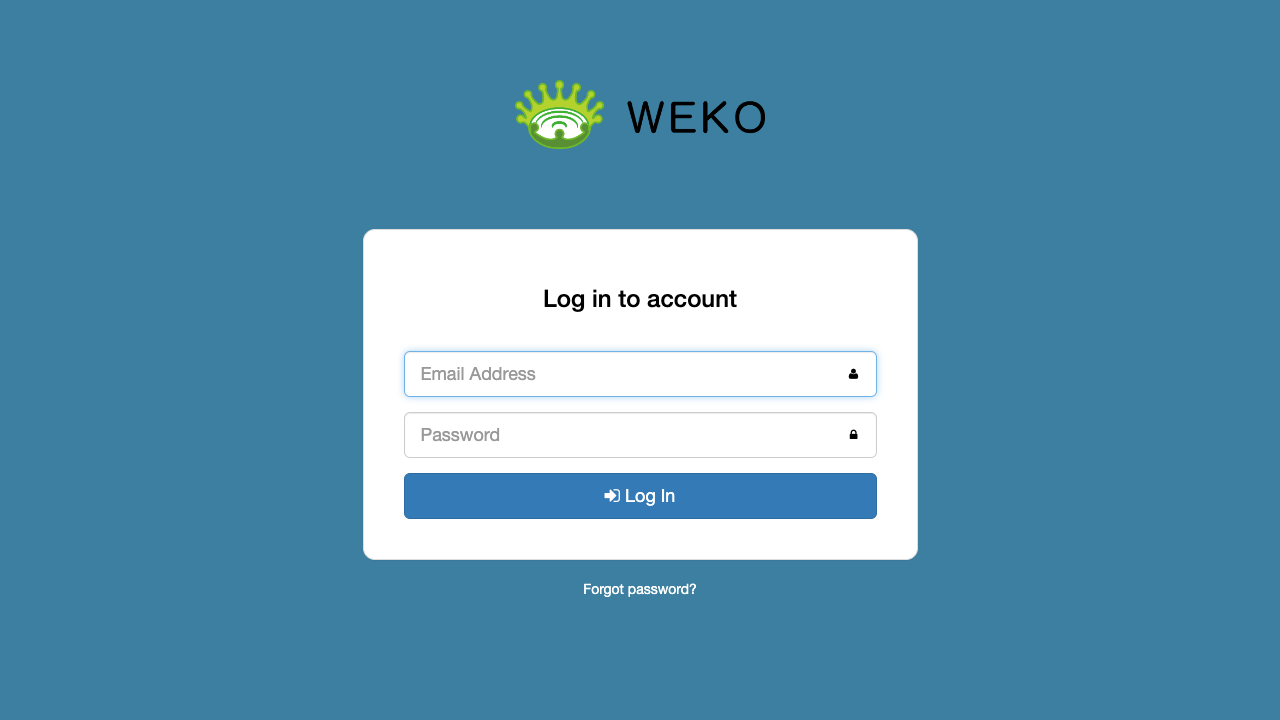

In [89]:
async def _step(page):
    await page.locator('//a[contains(@class, "login-button")]').click()
    await expect(page.locator('//input[@name = "email"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## WEKOアカウントを入力し、「Log in」をクリックする

WEKO3のアイテム画面が表示されること


Start epoch: 1764939462.917012 seconds


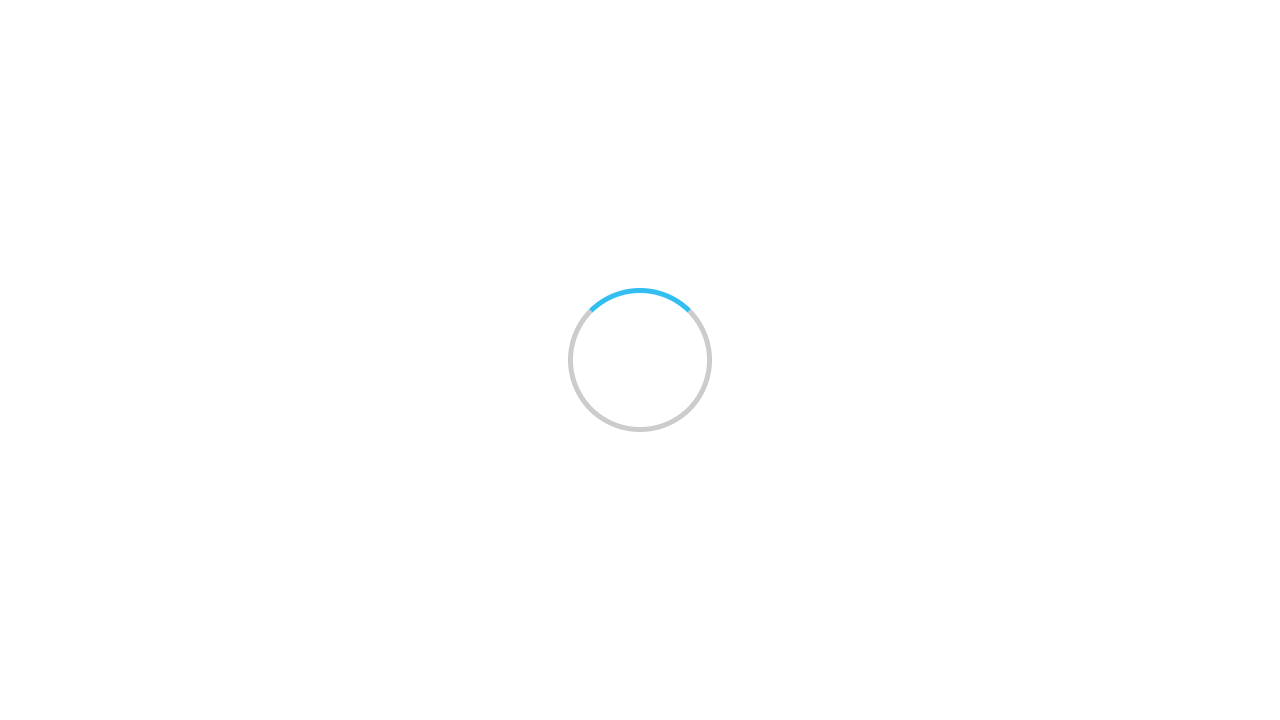

In [90]:
async def _step(page):
    await page.locator('//input[@name = "email"]').fill(weko_admin_email)
    await page.locator('//input[@name = "password"]').fill(weko_admin_password)
    await page.locator('//button[@type = "submit"]').click()
    await expect(page.locator('//a[@href = "/account/settings/profile/" and .//i[@class="fa fa-user"]]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 上部ナビゲーションバーの「▼」をクリックする

ドロップダウンが表示されること

Start epoch: 1764939464.116205 seconds


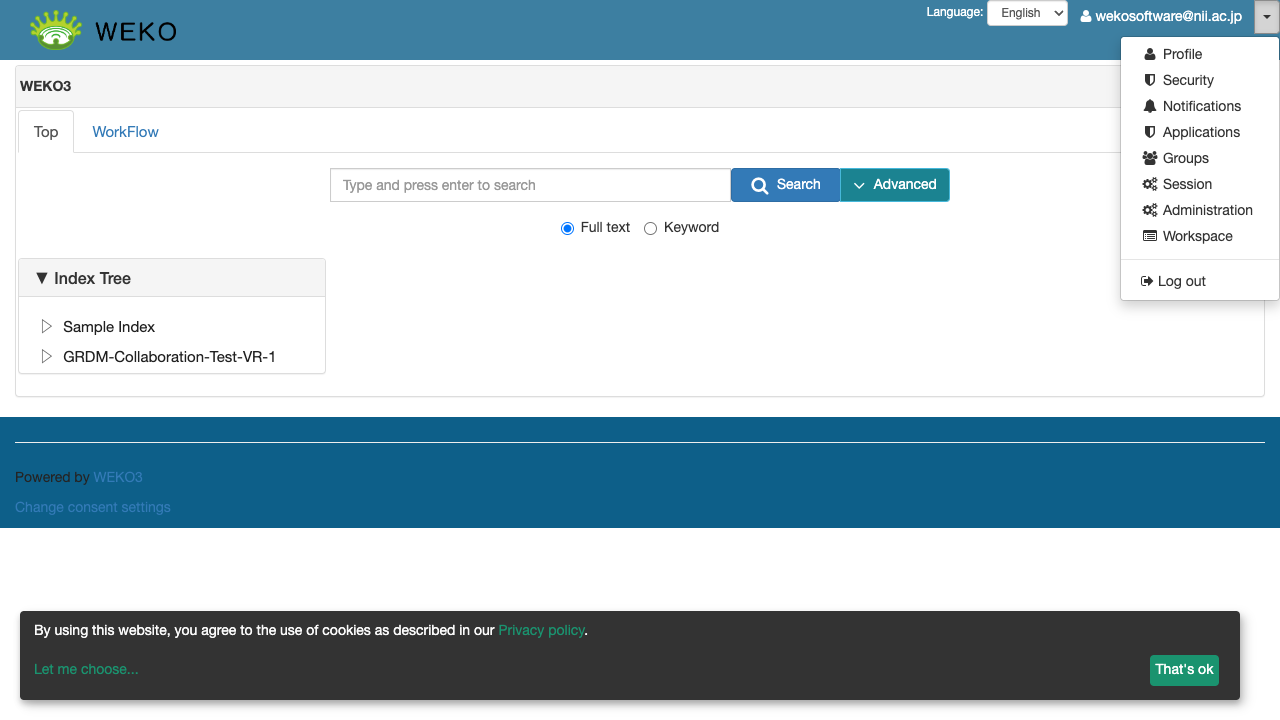

In [91]:
async def _step(page):
    await page.locator('//div[contains(@class, "navbar-form")]//button[contains(@class, "dropdown-toggle")]').click()
    await expect(page.locator('//a[@href = "/account/settings/applications/"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「Applications」をクリックする

Developer Applicationsが表示されること

Start epoch: 1764939465.104137 seconds


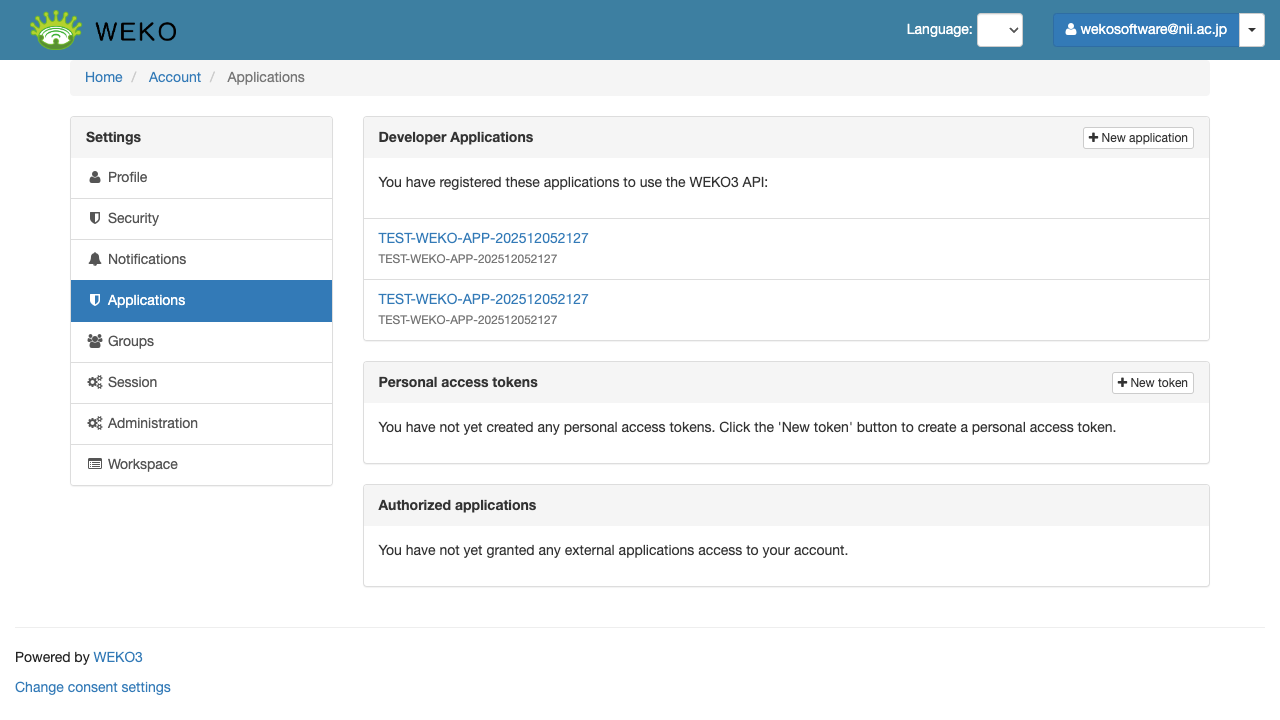

In [92]:
async def _step(page):
    await page.locator('//a[@href = "/account/settings/applications/"]').click()
    await expect(page.locator('//strong[contains(text(), "Developer Applications")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「New application」をクリックする

New OAuth Applicationフォームが表示されること

Start epoch: 1764939465.652245 seconds


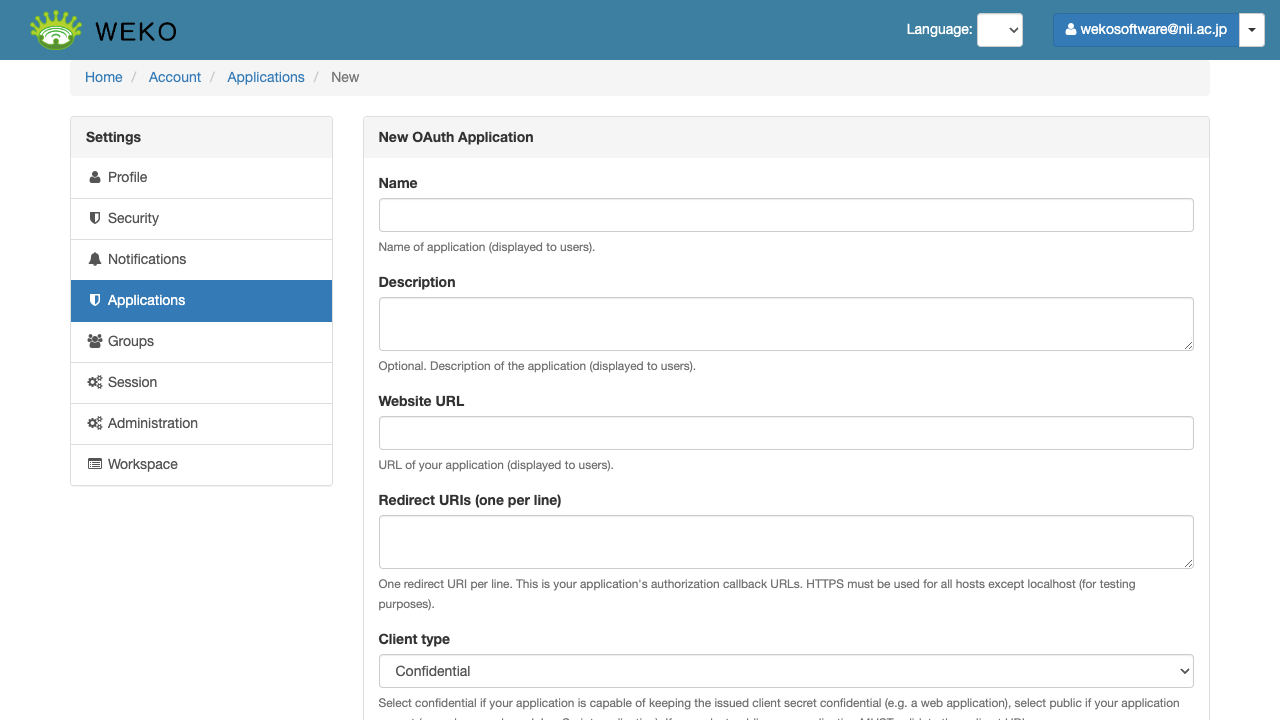

In [93]:
async def _step(page):
    await page.locator('//a[contains(text(), "New application")]').click()
    await expect(page.locator('//strong[contains(text(), "New OAuth Application")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## アプリケーション情報を入力し、「登録」をクリックする

フォームには以下の情報を入力する。Client IDとClient Secretが表示されること

- 名前: TEST-WEKO-APP-YYYYMMDDHHMM(実施時刻)
- 記述: TEST-WEKO-APP-YYYYMMDDHHMM(実施時刻)
- Website URL: (GakuNin RDMシステムのURL)
- Redirect URIs: (GakuNin RDMシステムのURL)/oauth/callback/weko/(WEKO3リポジトリのホスト名: 例えばweko3.rdm.nii.ac.jp)/
- Client type: Confidential

In [94]:
base_url = rdm_url[:-1] if rdm_url.endswith('/') else rdm_url
redirect_uri = f"{base_url}/oauth/callback/weko/{urlparse(weko_url).hostname}/"
application_description = oauth_application_name
print('Redirect URI:', redirect_uri)


Start epoch: 1764939466.180374 seconds
Retrieved client credentials from WEKO


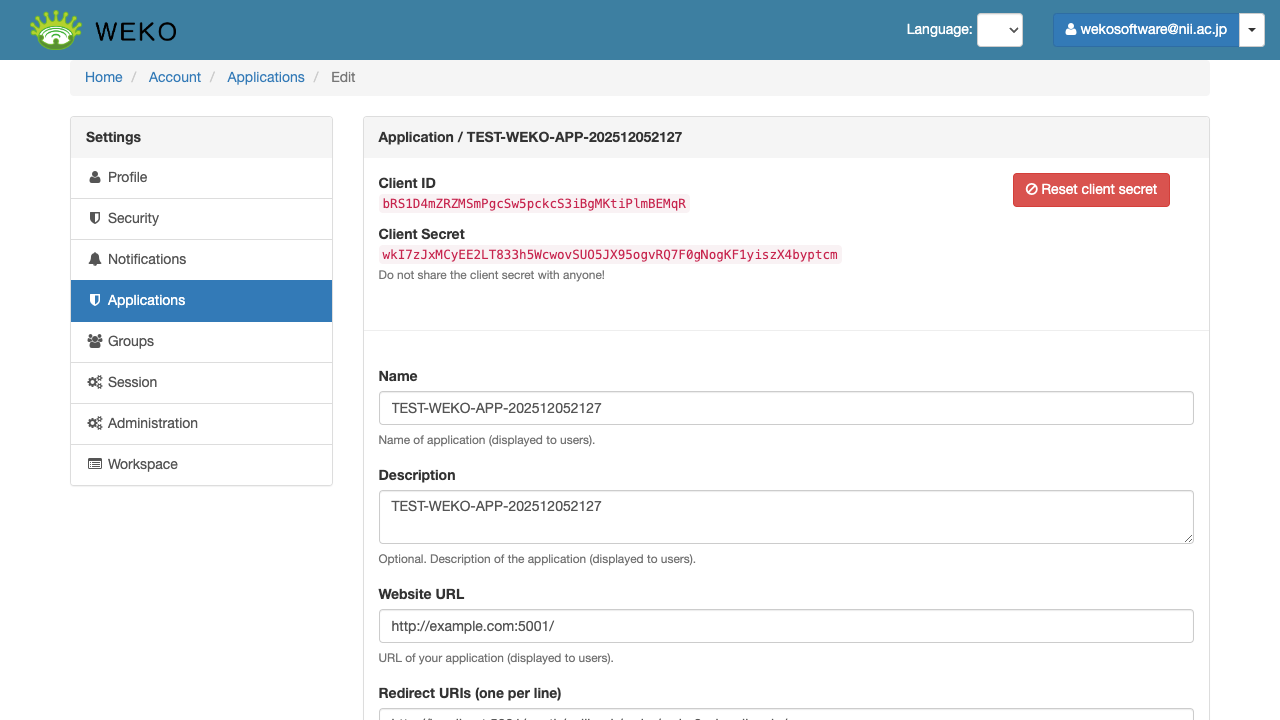

In [95]:
async def _step(page):
    await page.locator('//input[@name = "name"]').fill(oauth_application_name)
    await page.locator('//textarea[@name = "description"]').fill(application_description)
    # localhost:port は websiteに指定できないので置き換え
    website_url = rdm_url.replace('localhost', 'example.com')
    await page.locator('//input[@name = "website"]').fill(website_url)
    await page.locator('//textarea[@name = "redirect_uris"]').fill(redirect_uri)
    await page.locator('//button[@type = "submit"]').click()
    await expect(page.locator('//strong[text() = "Client ID"]')).to_be_visible(timeout=transition_timeout)
    global client_id, client_secret
    client_id = (await page.locator('//strong[text() = "Client ID"]/../code').inner_text()).strip()
    client_secret = (await page.locator('//strong[text() = "Client Secret"]/../code').inner_text()).strip()
    print('Retrieved client credentials from WEKO')

await run_pw(_step)


## 統合管理者画面のタブに戻り、JAIRO Cloudの「追加」をクリックする

「JAIRO Cloudアプリケーションの設定」ダイアログが表示されること

Start epoch: 1764939467.079489 seconds


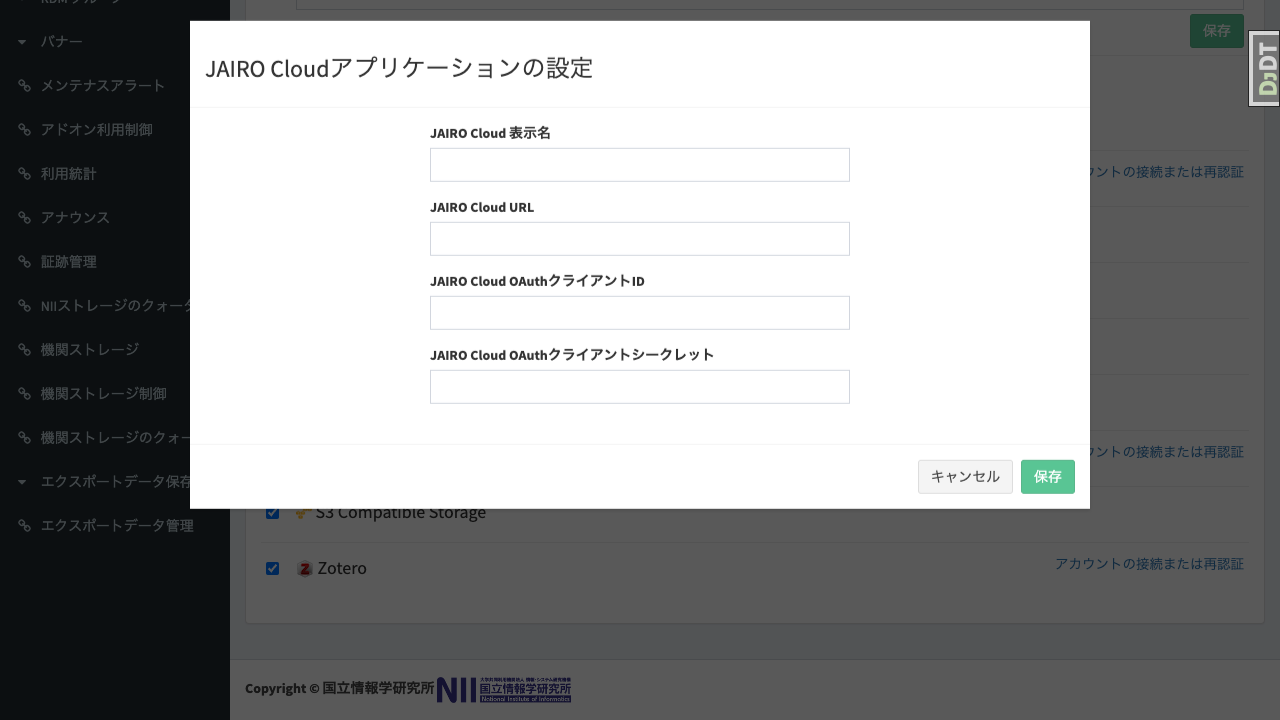

In [96]:
await close_latest_page()

async def _step(page):
    await page.locator('//button[@href = "#wekoInputHost"]').click()
    await expect(page.locator('//h3[text() = "JAIRO Cloudアプリケーションの設定"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## アプリケーション情報を入力し、「保存」をクリックする

アプリケーション情報は以下を入力する。OAuthアプリケーションに TEST-WEKO-APP-YYYYMMDDHHMM が表示されること

- JAIRO Cloud表示名: TEST-WEKO-APP-YYYYMMDDHHMM(実施時刻)
- JAIRO Cloud URL: WEKO3リポジトリのURL
- JAIRO Cloud OAuthクライアントID: WEKO3で発行されたClient ID
- JAIRO Cloud OAuthクライアントシークレット: WEKO3で発行されたClient Secret

Start epoch: 1764939467.539414 seconds


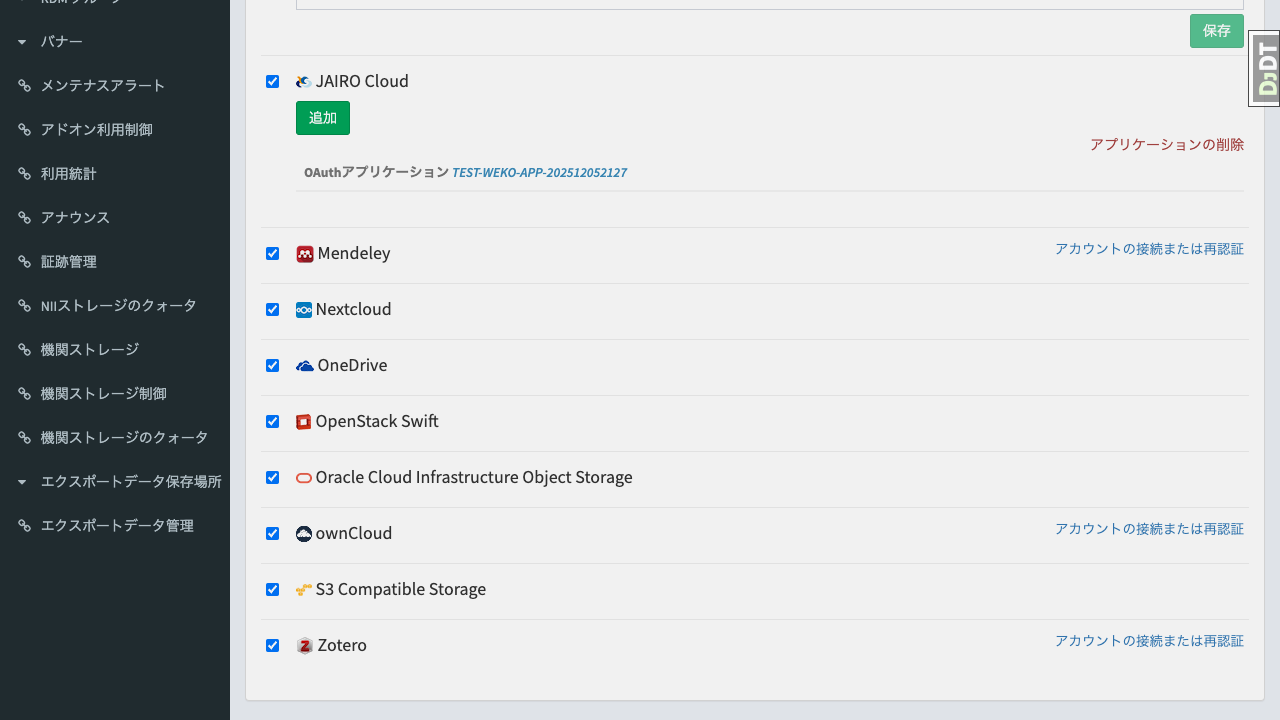

In [97]:
async def _step(page):
    await page.locator('//input[@name = "weko_name"]').fill(oauth_application_name)
    await page.locator('//input[@name = "weko_url"]').fill(weko_url)
    await page.locator('//input[@name = "weko_oauth_client_id"]').fill(client_id)
    await page.locator('//input[@name = "weko_oauth_client_secret"]').fill(client_secret)
    await page.locator('//input[@name = "weko_oauth_client_secret"]').press('Tab')
    await page.locator('//button[@data-bind = "click: addHost, enable: hostCompleted"]').click()
    await expect(page.locator(f'//em[text() = "{oauth_application_name}"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 統合管理者画面のタブを閉じる

統合管理者画面での設定が完了したら、このタブを閉じてユーザー側のブラウザに戻る。

Start epoch: 1764939468.057525 seconds


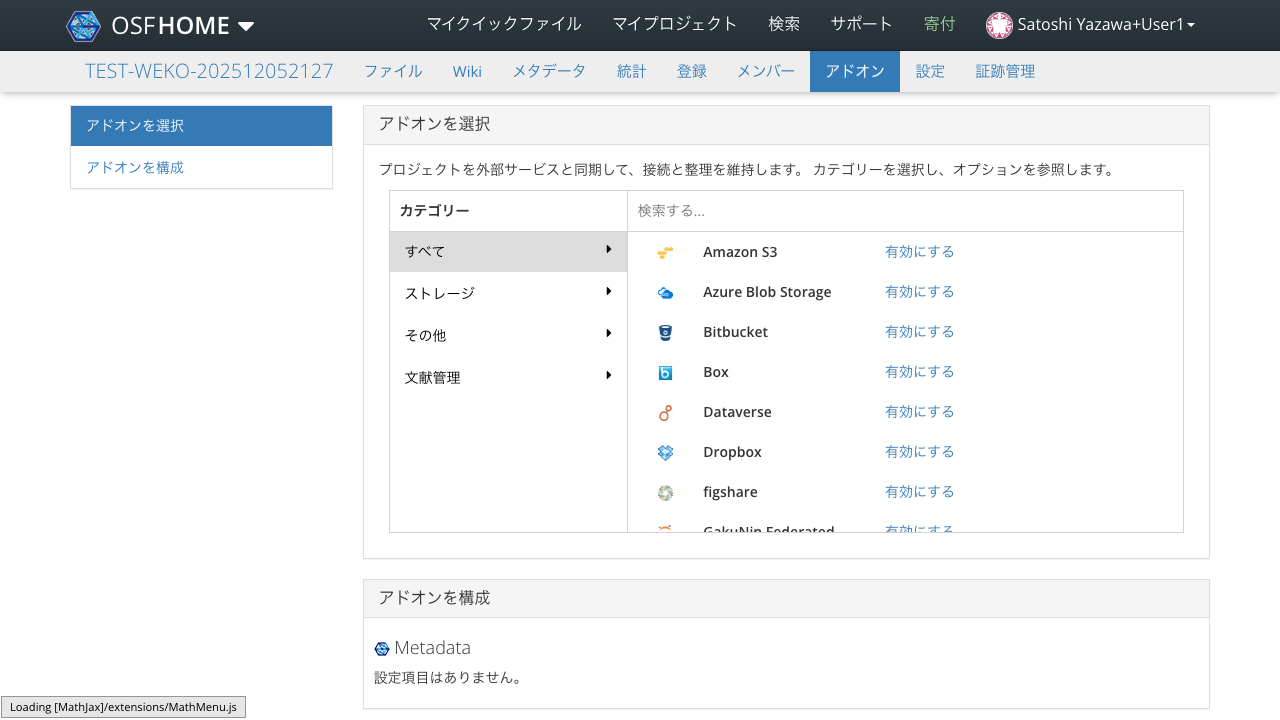

In [98]:
async def _step(page):
    await page.goto(project_url)
    await expect(page.locator('//span[@id = "nodeTitleEditable"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await page.locator('//a[text() = "アドオン"]').click()
    await expect(page.locator('//div[@full_name = "JAIRO Cloud"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## アドオン設定のタブを再読み込みする

JAIRO Cloudアドオンが表示されることを確認する。

Start epoch: 1764939469.7209501 seconds


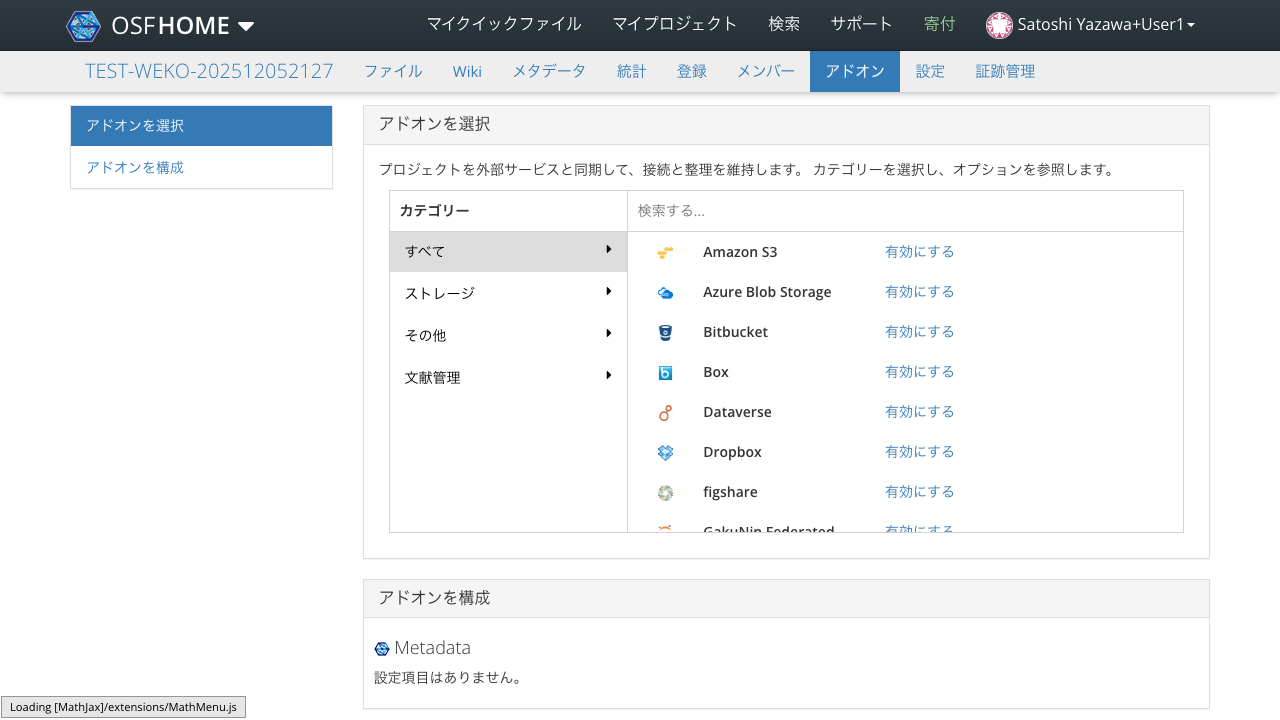

In [99]:
async def _step(page):
    await page.reload()
    await expect(page.locator('//div[@full_name = "JAIRO Cloud"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「アドオンを選択」のパネル内「JAIRO Cloud」の行の「有効にする」をクリックする

「JAIRO Cloudアドオン規約」のダイアログが表示されること

Start epoch: 1764939470.3715332 seconds


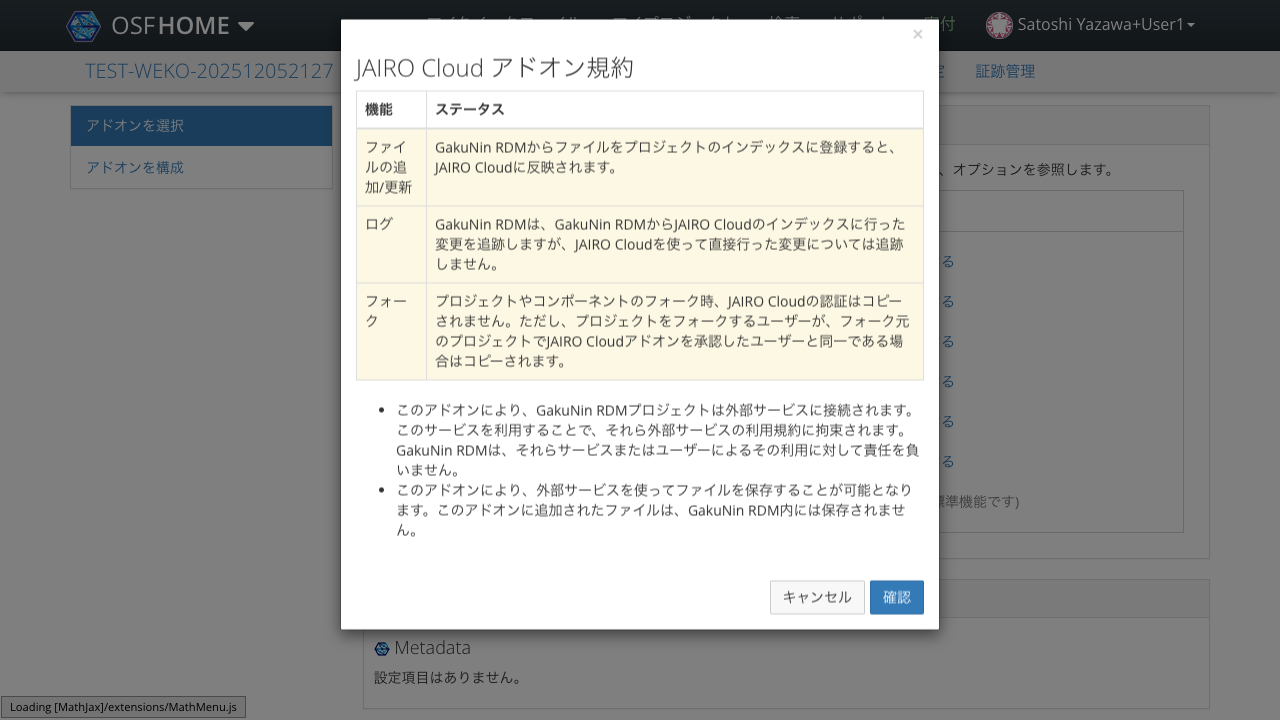

In [100]:
async def _step(page):
    enable_button = page.locator('//div[@full_name = "JAIRO Cloud"]//a[text() = "有効にする"]')
    if await enable_button.count():
        await enable_button.click()
        await expect(page.locator('//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)
    else:
        print('JAIRO Cloud addon is already enabled for this project')

await run_pw(_step)


## 「確認」をクリックする

「アドオンを構成」のパネル内に「JAIRO Cloud」の行が追加されること

Start epoch: 1764939470.844981 seconds


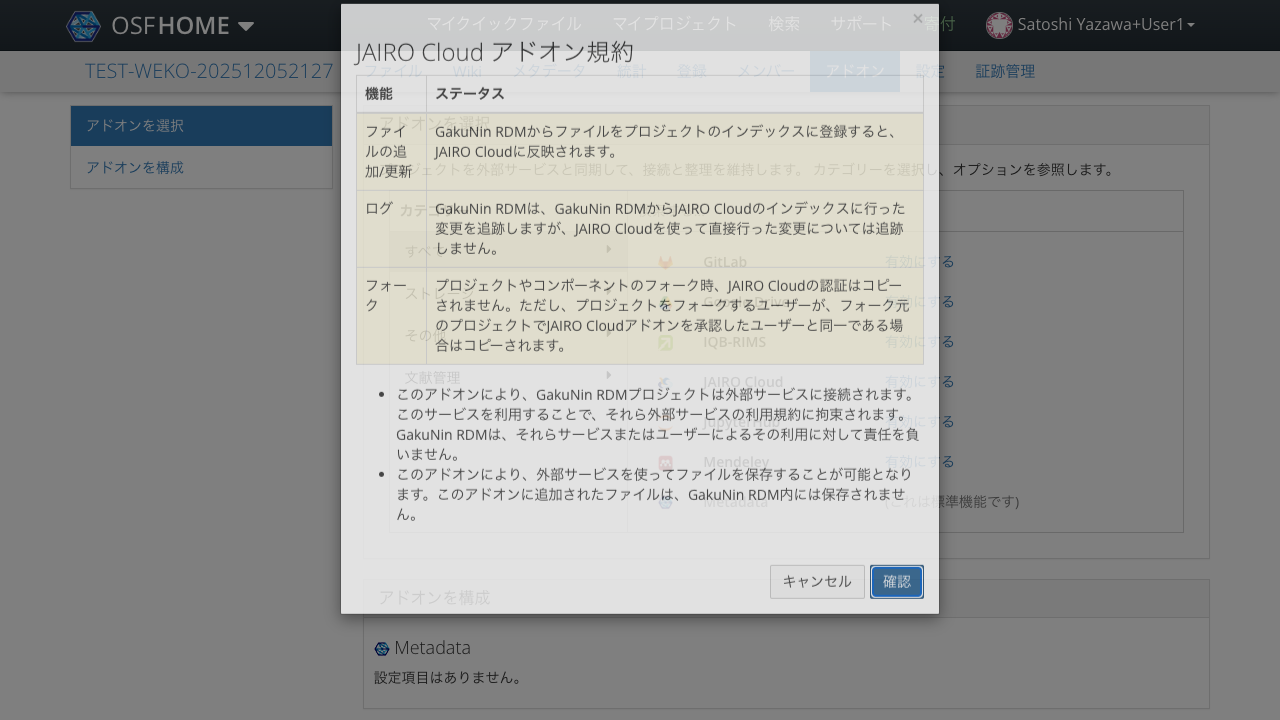

In [101]:
async def _step(page):
    confirm_button = page.locator('//button[@data-bb-handler = "confirm"]')
    if await confirm_button.count():
        await confirm_button.click()
    await expect(page.locator('//img[@src = "/static/addons/weko/comicon.png"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


In [102]:
connect_link_text = None


## 「アカウントに接続する」または「プロフィールからアカウントをインポート」リンクをクリックする

「アカウントに接続する」リンクの場合は「JAIRO Cloudアカウントに接続」ダイアログが、「プロフィールからアカウントをインポート」リンクの場合はWEKOアカウントに接続しますか？ダイアログが表示されること

Start epoch: 1764939637.192121 seconds


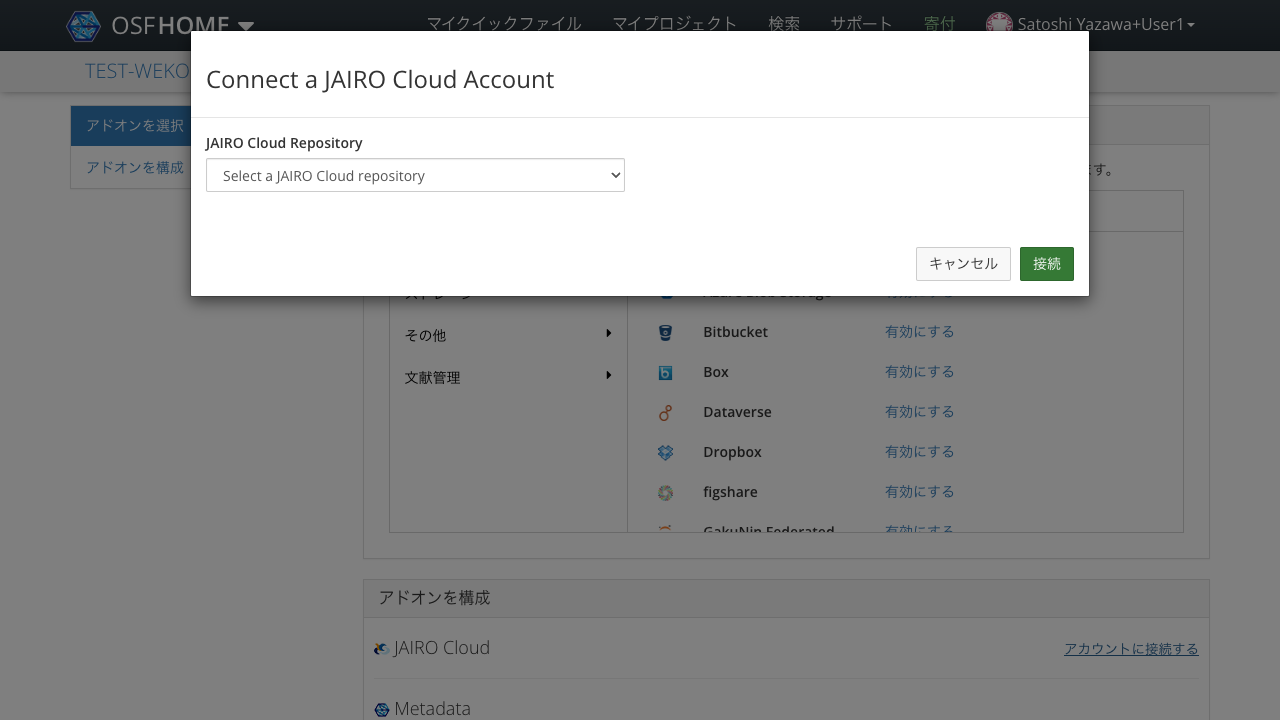

In [ ]:
async def _step(page):
    trigger = page.locator('//img[@src = "/static/addons/weko/comicon.png"]/..//a[contains(text(), "アカウント")]')
    global connect_link_text
    connect_link_text = await trigger.inner_text()
    await trigger.click()
    await expect(page.locator('//*[contains(@class, "modal-content")]//h3[contains(text(), "JAIRO Cloud")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


##  表示されたリンクが「アカウントに接続する」の場合: WEKOリポジトリとして TEST-WEKO-APP-YYYYMMDDHHMM を選択する 

選択した値が表示されること



Start epoch: 1764939645.195528 seconds


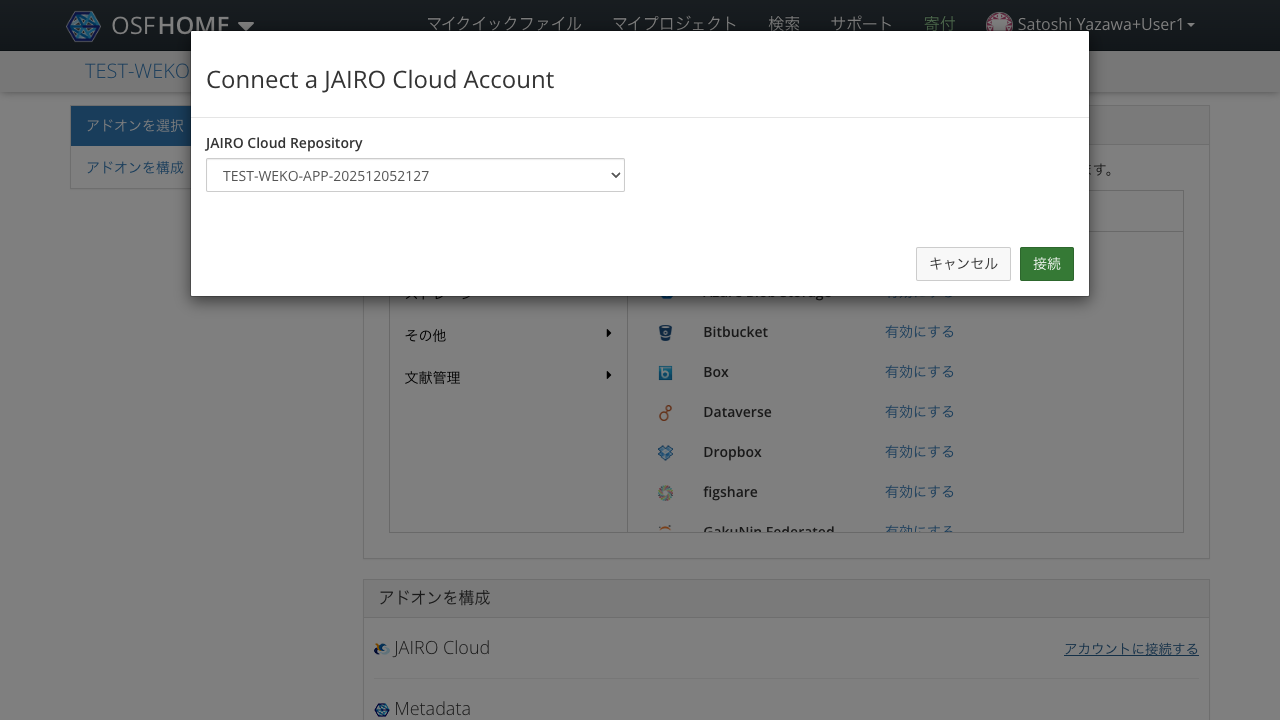

In [105]:
async def _step(page):
    if connect_link_text and 'アカウントに接続する' in connect_link_text:
        selector = page.locator('//select[@id = "hostSelect"]')
        await expect(selector).to_be_visible(timeout=transition_timeout)
        await selector.select_option(label=oauth_application_name)
    else:
        print('Host selection is skipped because the profile import flow is used')

await run_pw(_step)


##  表示されたリンクが「アカウントに接続する」の場合: 「接続」をクリックし、WEKOログインページでWEKOログインを実施し、「Authorize application」をクリックする

GRDMのアドオン設定画面に戻り、「JAIRO Cloudアカウントに接続しますか？」ダイアログが表示されること


In [ ]:
async def _step(page):
    if connect_link_text and 'アカウントに接続する' in connect_link_text:
        popup_future = page.wait_for_event('popup')
        await page.locator('//button[@data-bind = "click: connectOAuth"]').click()
        popup = await popup_future
        # await popup.locator('//input[@name = "email"]').fill(weko_user_email)
        # await popup.locator('//input[@name = "password"]').fill(weko_user_password)
        # await popup.locator('//button[@type = "submit"]').click()
        await popup.locator('//button[contains(text(), "Authorize application")]').click()
        await asyncio.sleep(10)  # wait for close
    else:
        print('OAuth popup is not required in this flow')

await run_pw(_step)


Start epoch: 1764939743.689638 seconds
Screenshot: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj8kmxygy/last-screenshot.png


AttributeError: 'Page' object has no attribute 'wait_for_close'

Start epoch: 1764939913.216099 seconds


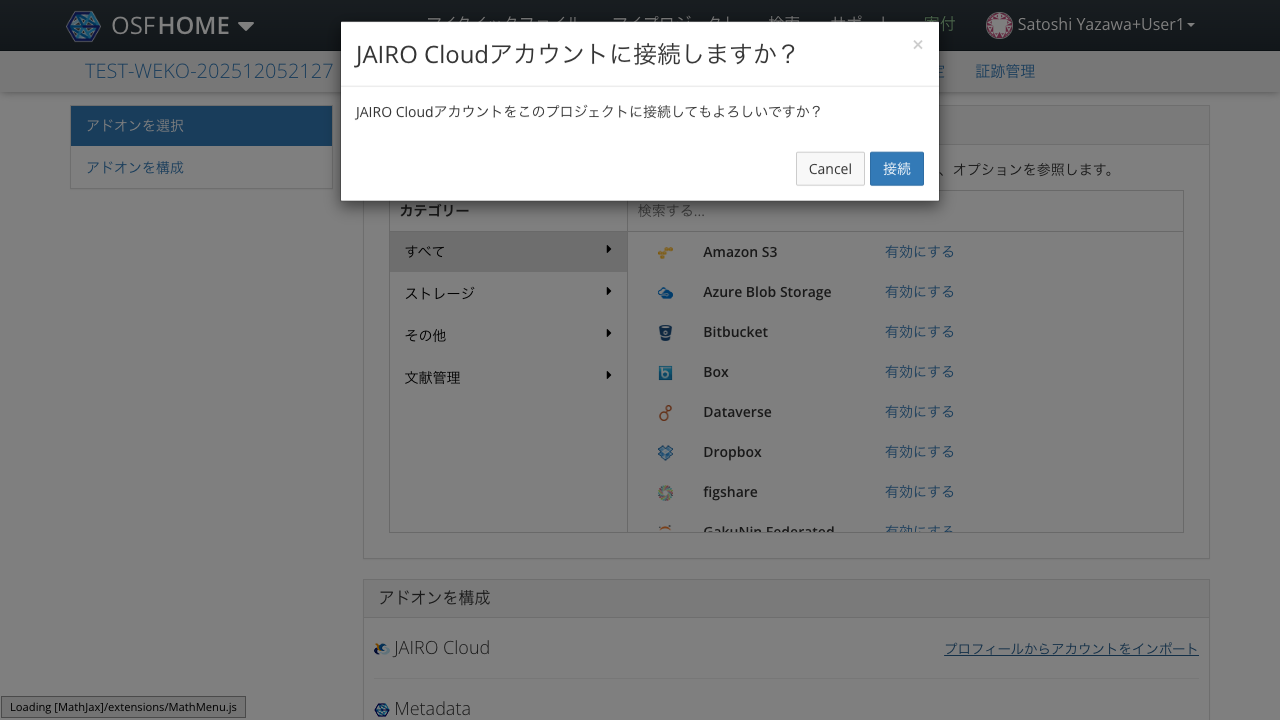

In [111]:
async def _step(page):
    if connect_link_text and 'アカウントに接続する' in connect_link_text:
        await page.reload()
        await page.locator('//img[@src = "/static/addons/weko/comicon.png"]/..//a[contains(text(), "アカウント")]').click()
    await expect(page.locator('//*[contains(@class, "modal-content")]//button[text() = "接続" and @data-bb-handler="confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


##  「接続」をクリックする

JAIRO Cloudアカウントに接続しますか？ダイアログが閉じること


Start epoch: 1764939990.496712 seconds


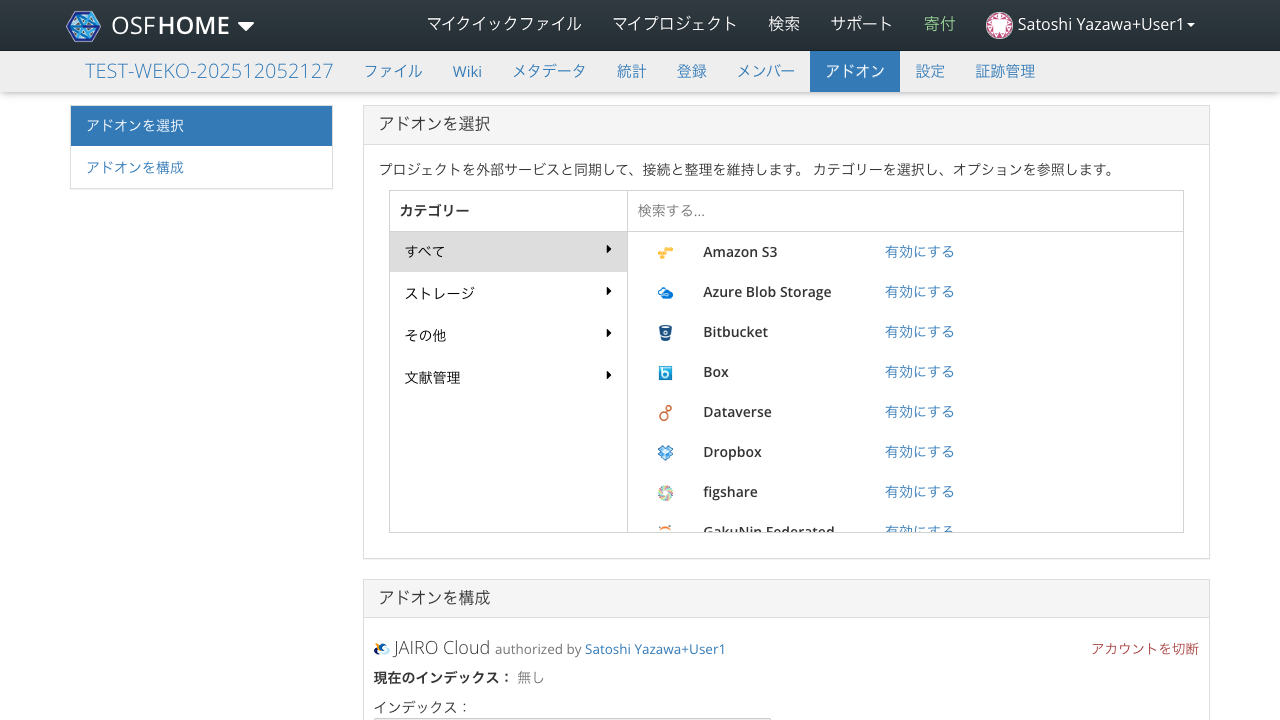

In [ ]:
async def _step(page):
    await page.locator('//*[contains(@class, "modal-content")]//button[text() = "接続" and @data-bb-handler="confirm"]').click()
    await expect(page.locator('//*[contains(text(), "authorized by")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


##  インデックス「TestJ」を選択する

ドロップダウンに TestJ と表示されること


Start epoch: 1764939997.057429 seconds


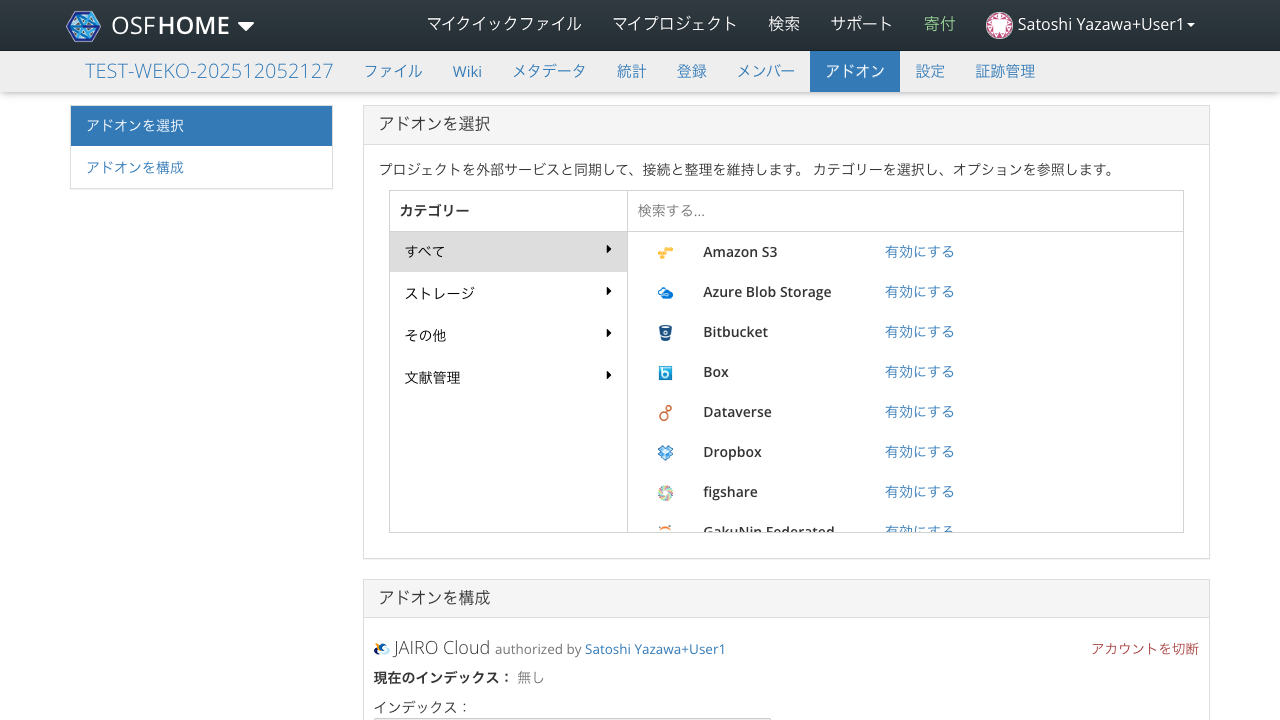

In [115]:
async def _step(page):
    select_box = page.locator('//div[contains(@class, "weko-settings")]//select')
    await select_box.select_option(label=weko_index_name)

await run_pw(_step)


##  「保存」をクリックする

現在のインデックス: Index for Testと表示されること


Start epoch: 1764940114.769732 seconds


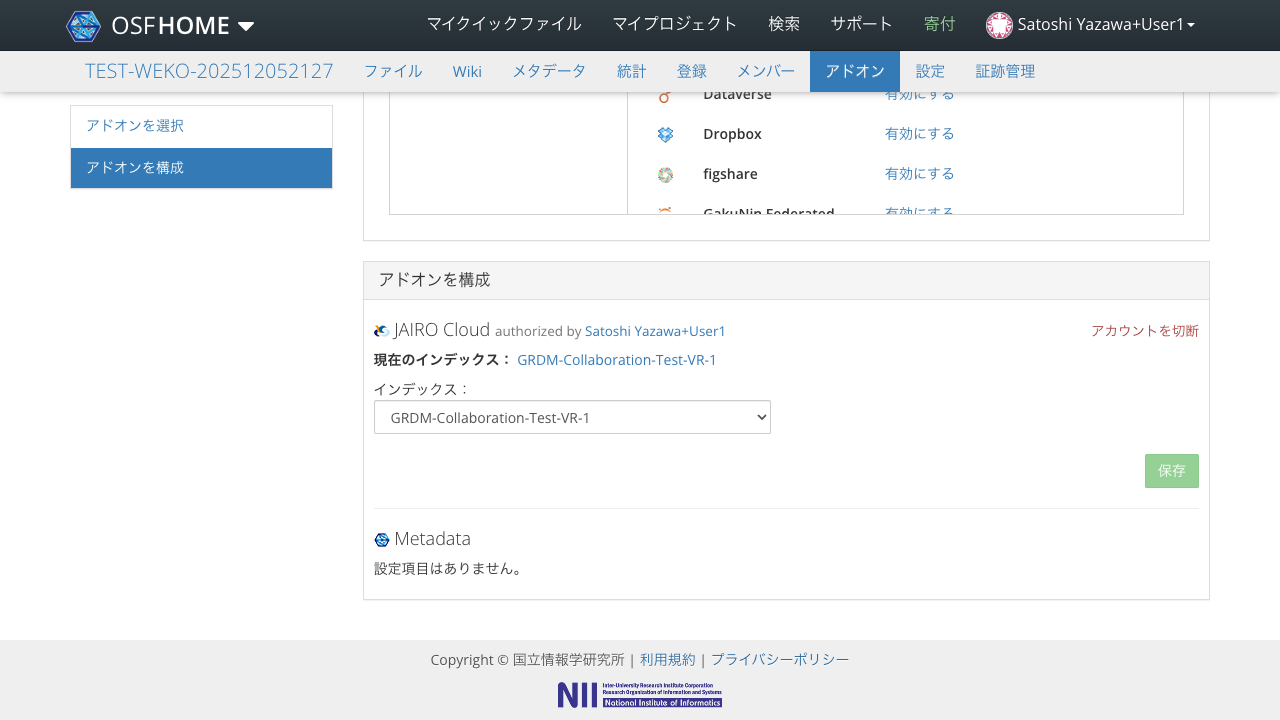

In [ ]:
async def _step(page):
    await page.locator('//div[contains(@class, "weko-settings")]//button[contains(text(), "保存")]').click()
    await expect(page.locator(f'//div[contains(@class, "weko-settings")]//a[contains(text(), "{weko_index_name}")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「確認」をクリックする

「アドオンを構成」のパネル内に「Metadata」の行が追加され、かつ、上部メニューに「メタデータ」タブが追加されること

Start epoch: 1764940128.651649 seconds


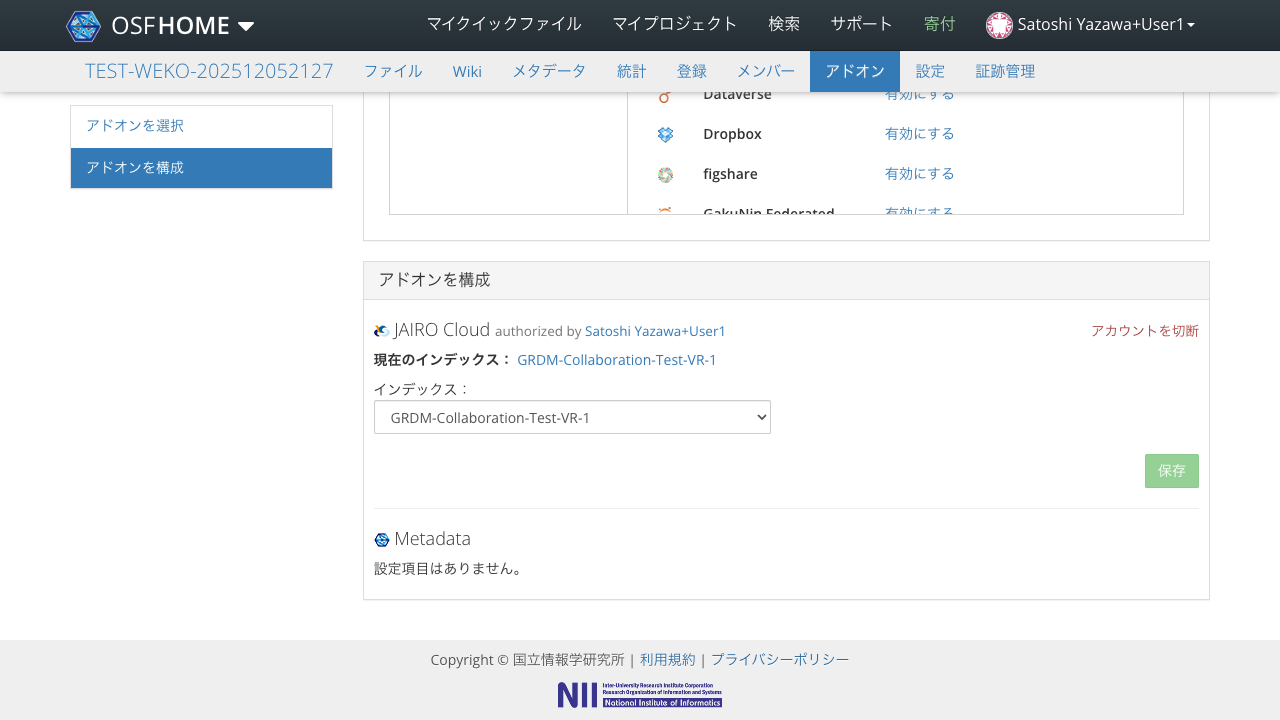

In [120]:
async def _step(page):
    confirm_button = page.locator('//button[@data-bb-handler = "confirm"]')
    if await confirm_button.count():
        await confirm_button.click()
    await expect(page.locator('//a[contains(text(), "メタデータ")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「(プロジェクト名)」をクリックする

プロジェクトダッシュボードページが表示されること

Start epoch: 1764940128.782358 seconds


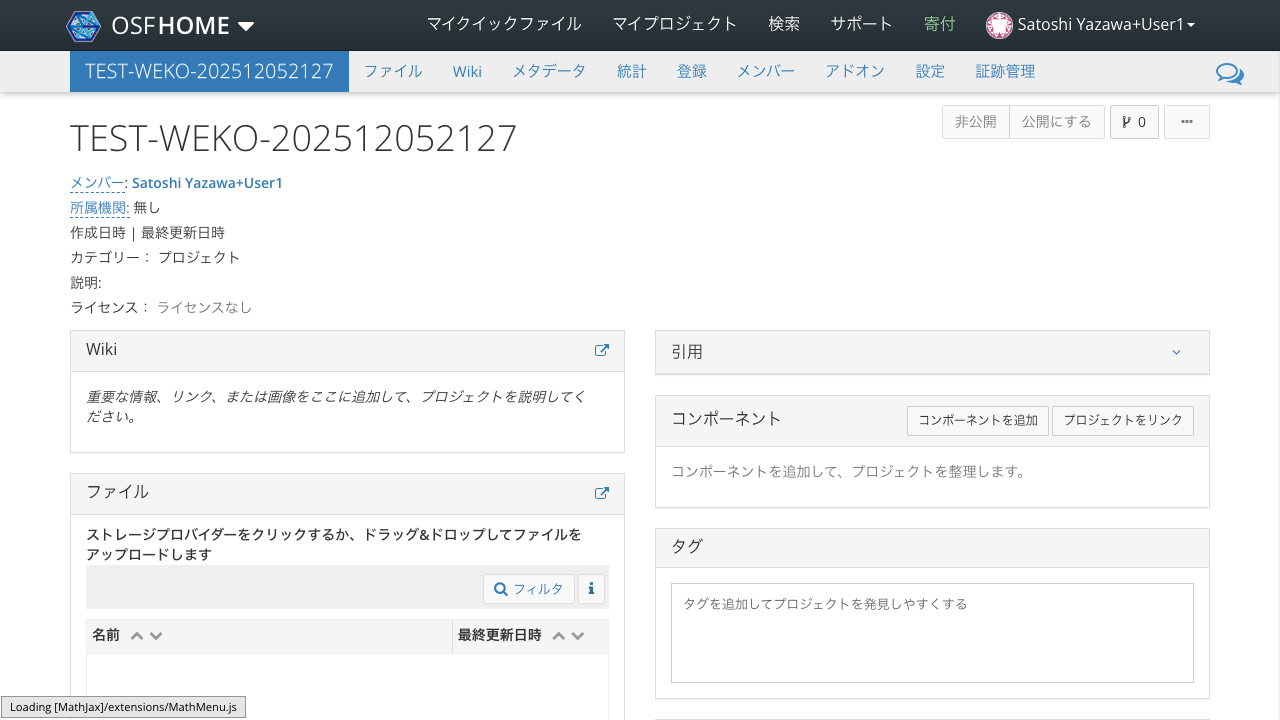

In [121]:
async def _step(page):
    await page.locator(f'//a[contains(text(), "{project_name}")]').click()
    await expect(page.locator(f'//*[text() = "{default_storage_label}"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「JAIRO Cloud: (インデックス名)」をクリックする

「新規フォルダ作成」ボタンが表示されること (表示まで数秒かかる可能性がある)

Start epoch: 1764940130.2593641 seconds


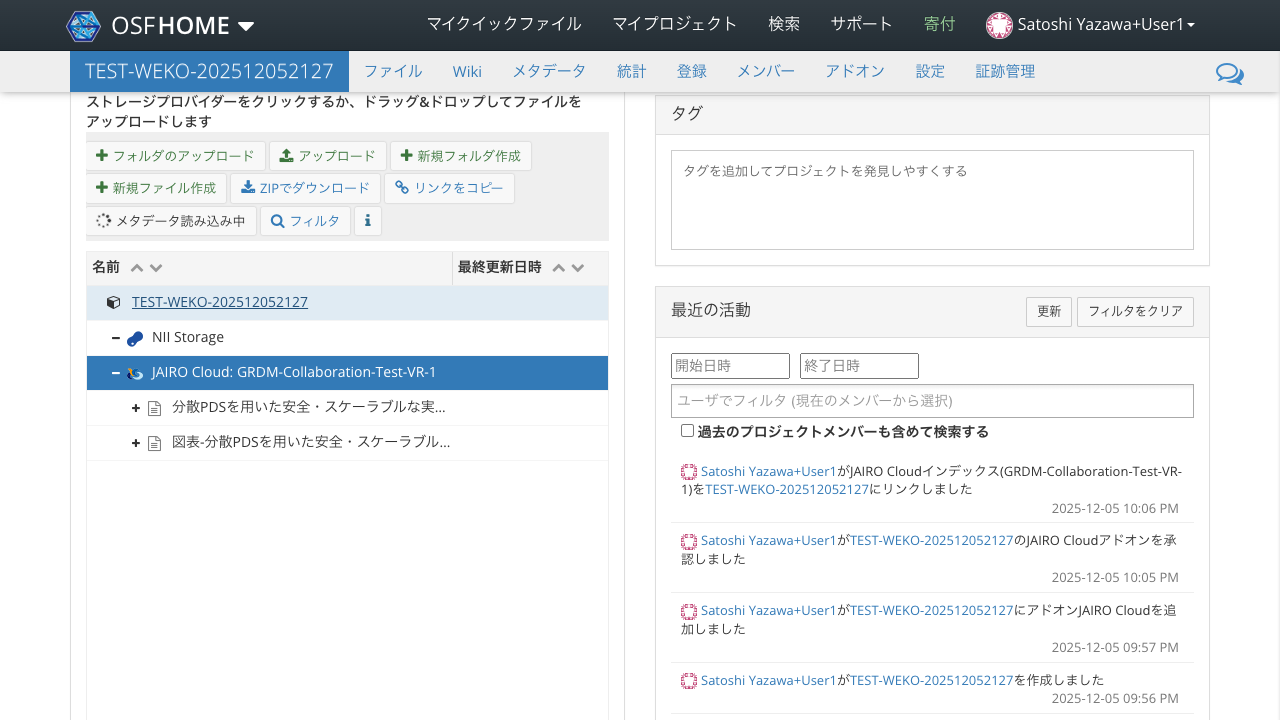

In [122]:
async def _step(page):
    target_label = f'JAIRO Cloud: {weko_index_name}'
    await page.locator(f'//*[text() = "{target_label}"]').click()
    await expect(page.locator('//*[text() = "新規フォルダ作成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「新規フォルダ作成」をクリックする

フォルダ名入力テキストフィールドが表示されること

Start epoch: 1764940133.4070349 seconds


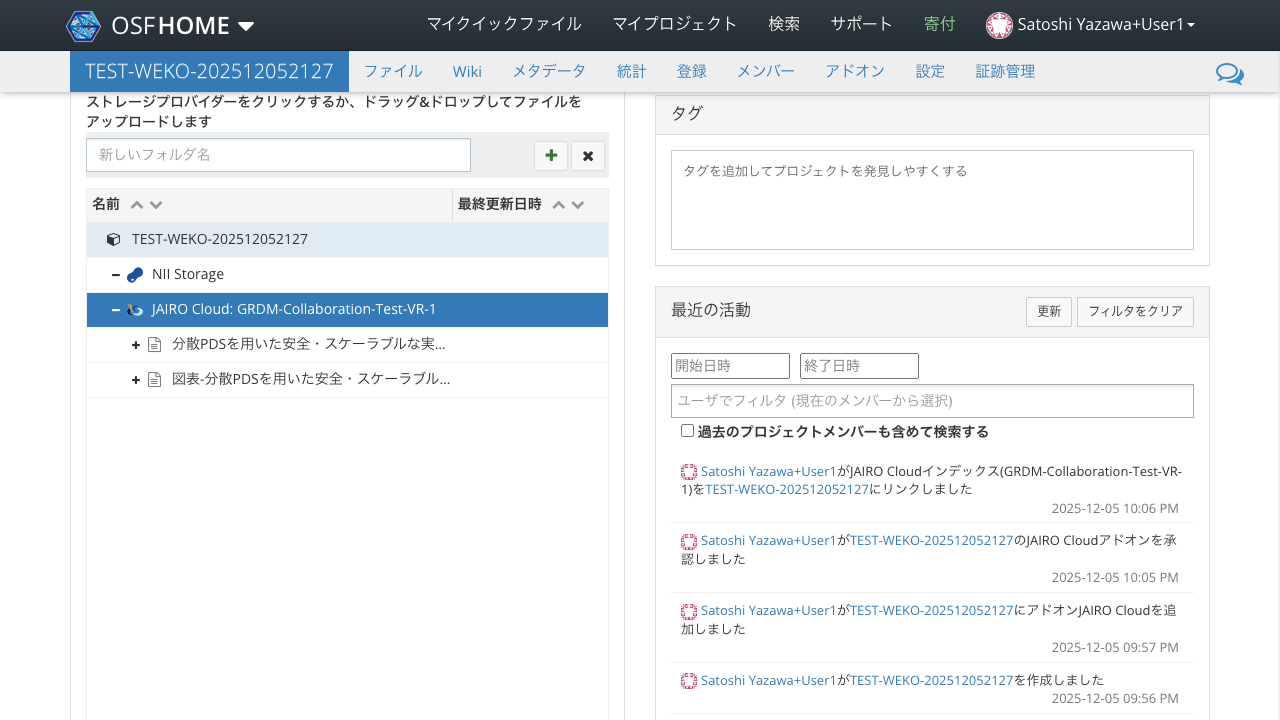

In [123]:
async def _step(page):
    await page.locator('//*[text() = "新規フォルダ作成"]').click()
    await expect(page.locator('//input[@id = "createFolderInput"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「TESTFOLDER(ENTER)」を入力する

「TESTFOLDER [Draft]」と表示されること

Start epoch: 1764940133.553767 seconds


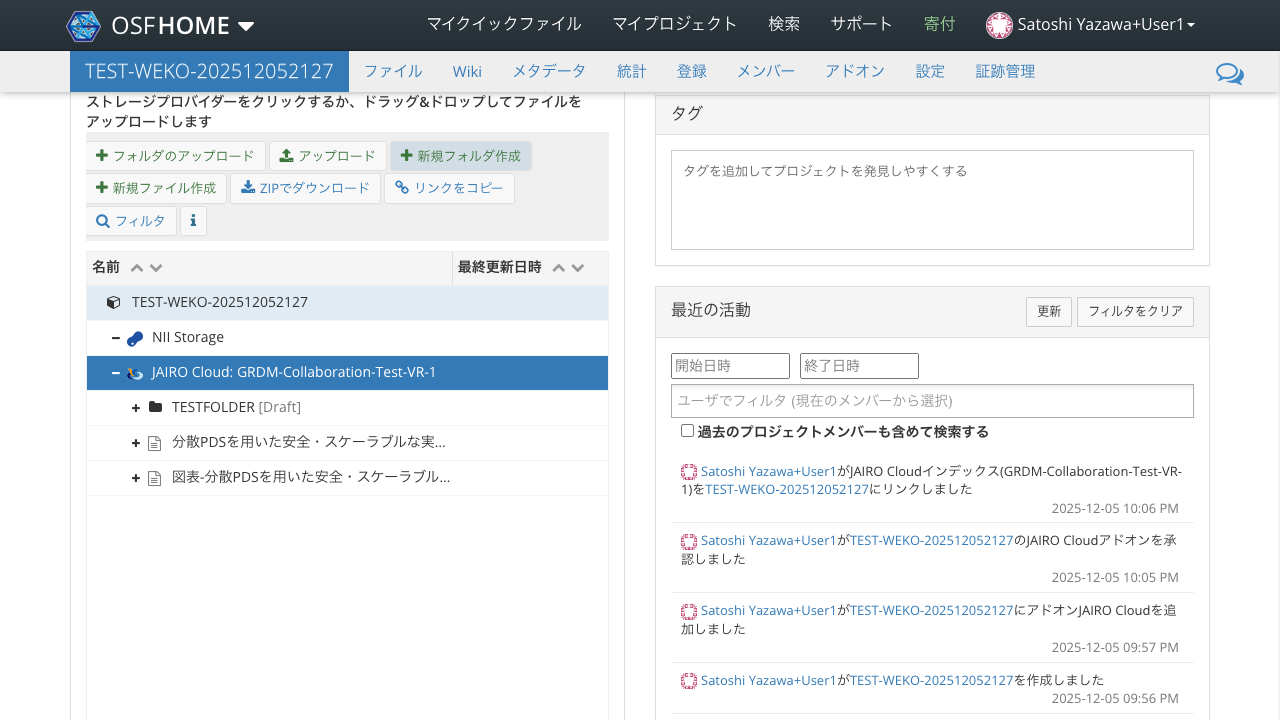

In [124]:
async def _step(page):
    folder_input = page.locator('//input[@id = "createFolderInput"]')
    await folder_input.fill('TESTFOLDER')
    await folder_input.press('Enter')
    await expect(page.locator('//*[text() = "TESTFOLDER"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「TESTFOLDER」のアイコンをクリックする

「フォルダを削除」ボタンが表示されること

Start epoch: 1764940138.664279 seconds


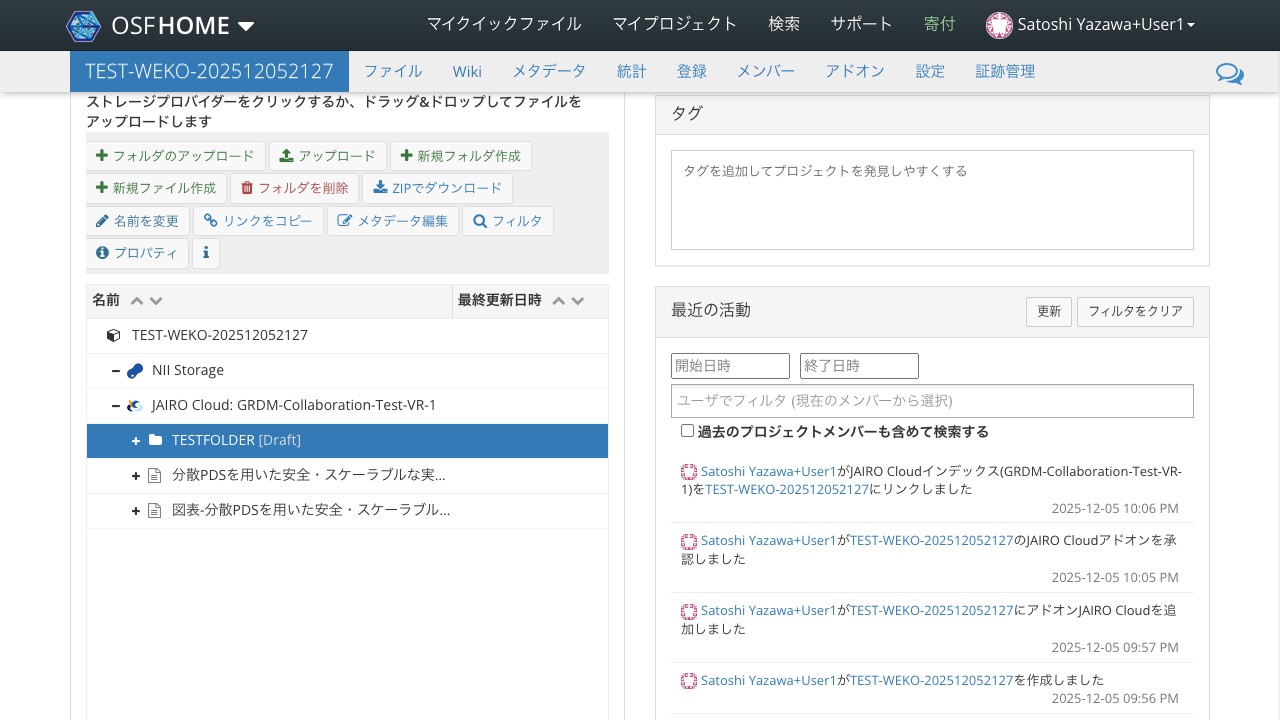

In [125]:
async def _step(page):
    await page.locator('//*[text() = "TESTFOLDER"]/../../..//i[contains(@class, "fa-folder")]').click()
    await expect(page.locator('//*[text() = "フォルダを削除"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「フォルダを削除」をクリックする

「"TESTFOLDER"を削除しますか？」ダイアログが表示されること

Start epoch: 1764940138.882745 seconds


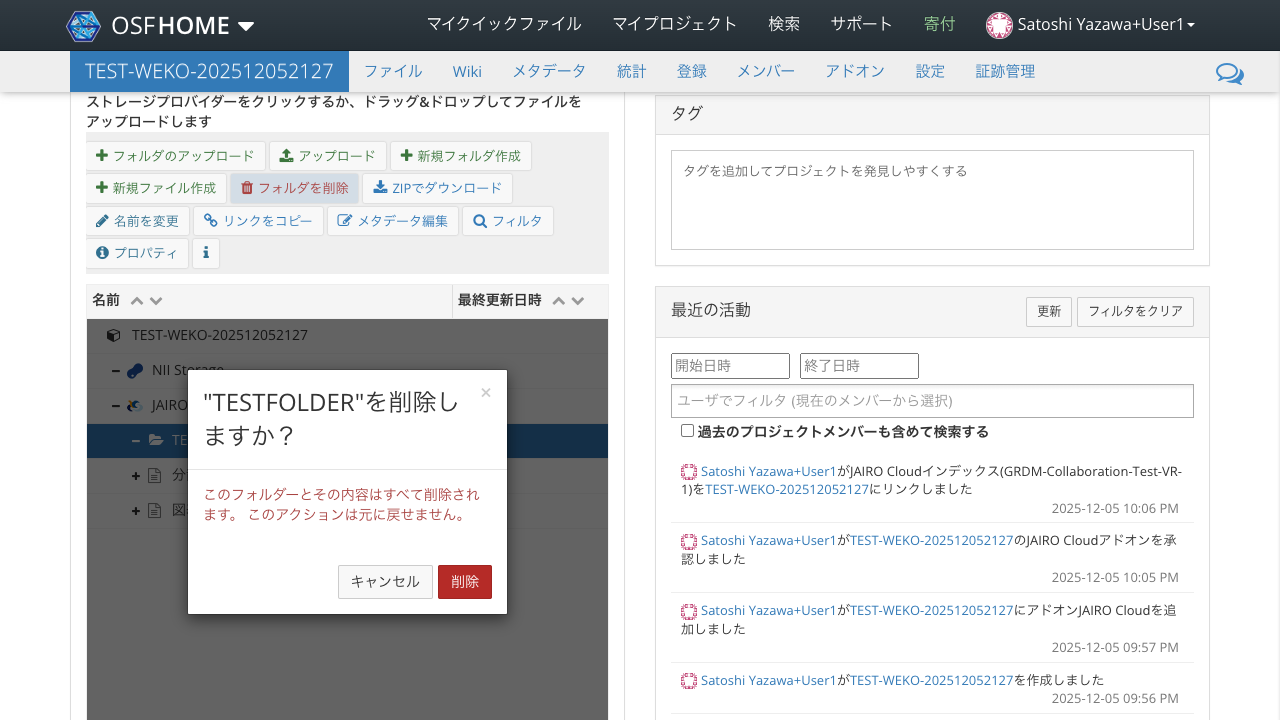

In [126]:
async def _step(page):
    await page.locator('//*[text() = "フォルダを削除"]').click()
    await expect(page.locator('//h3[contains(text(), "削除しますか")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「削除」をクリックする

TESTFOLDERフォルダが削除されること

Start epoch: 1764940145.905005 seconds


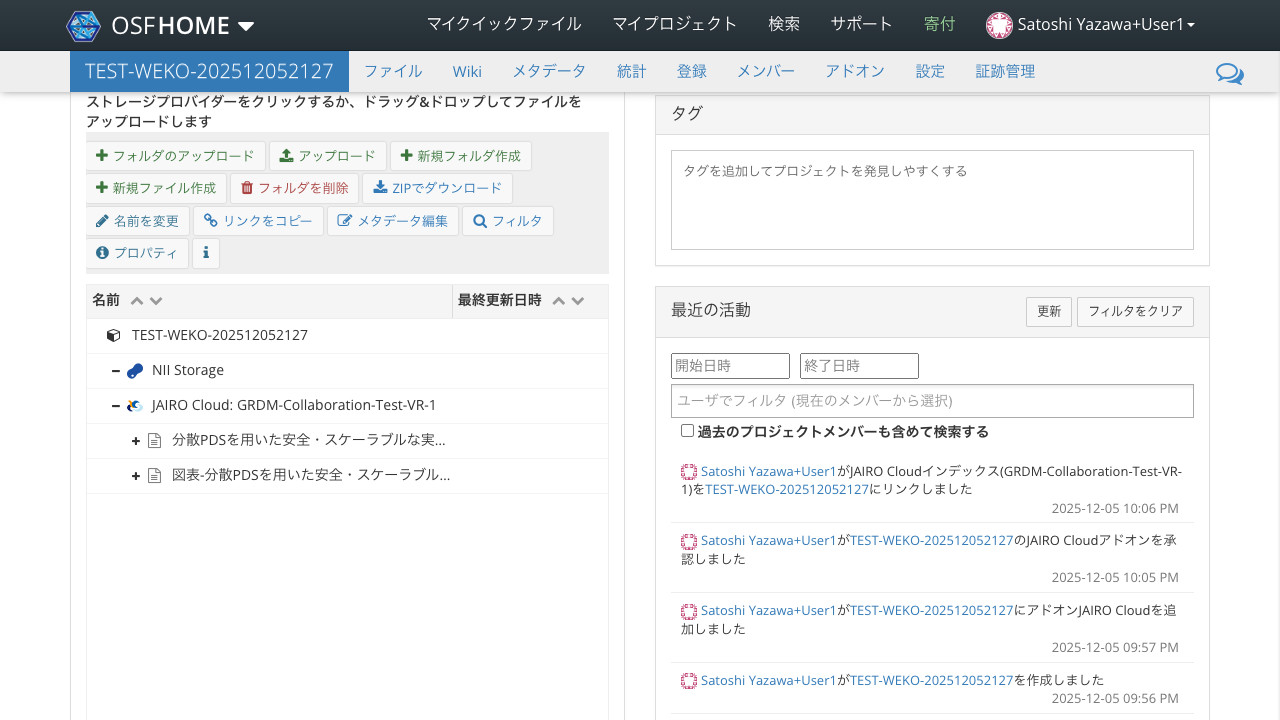

In [127]:
async def _step(page):
    await page.locator('//h3[contains(text(), "削除しますか")]/../..//*[contains(@class, "btn-danger") and text() = "削除"]').click()
    await expect(page.locator('//*[text() = "TESTFOLDER"]')).to_have_count(0)

await run_pw(_step)


後始末

In [ ]:
await finish_pw_context(screenshot=False, last_path=default_result_path)


Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj8kmxygy/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj8kmxygy/har.zip
Console: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpj8kmxygy/console.log


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-yamaji/RDM-e2e-test-nb/scripts/playwright.py", line 186, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmprecag_ik/videos/0a825b6b5975009c442ddf179899cc82.webm'


In [ ]:
!rm -fr {work_dir}
